<a href="https://colab.research.google.com/github/RMRL/RMRL_AIFFEL_Quest_Eng-/blob/main/Day2_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

last modified date : 2026.05  
제작 : 모두의연구소

# Day 2 실습 — Advanced·Modular RAG + RAGAS 평가

# 들어가며

Day 1에서는 가장 기본형인 **Naive RAG** 파이프라인을 직접 구현해 보았습니다. 이번 실습에서는 한국어 QA 벤치마크 **KorQuAD v1** 데이터셋 위에서 **Advanced·Modular RAG** 의 핵심 기법(Multi-Query, RAG-Fusion, HyDE, Reranking, Self-RAG)을 단계적으로 적용하고, 그 결과를 **RAGAS** 로 정량 평가합니다.

이번 실습이 끝나면 다음을 직접 말할 수 있게 됩니다.
- Naive RAG 대비 **어떤 단계**를 보강하면 정답률이 올라가는가
- Multi-Query / RAG-Fusion / HyDE / Reranker / Self-RAG 는 각각 **어떤 코드 라인**으로 적용하는가
- RAGAS 의 4대 지표(Faithfulness · Answer Relevance · Context Precision · Context Recall)는 어떻게 계산되고 어떻게 읽는가
- 내 RAG 가 ‘얼마나 좋아졌는지’를 **숫자로** 보여주는 방법

## Step 0 : 설치와 준비  
Day 1과 동일하게 Colab에서 진행한다고 가정합니다.

In [1]:
# Colab pre-installed langchain 0.3 / ragas 0.1~0.4 를 ragas 0.2.10 호환 조합으로 정리합니다.
# 처음 실행 시 약 3~5분 걸립니다. 진행률 출력을 보면서 기다리세요 (멈춘 게 아닙니다).

# 1) 기존 langchain / ragas 패키지 제거 — 버전 충돌로 인한 pip resolver 백트래킹 방지
!pip uninstall -y ragas ragas-experimental langchain langchain-core langchain-community langchain-openai langchain-text-splitters langchain-chroma

# 2) 0.2 시리즈 패치 버전까지 핀 설치 — resolver 부담 최소화 (-q 제거해서 진행률 보이게)
!pip install --no-cache-dir \
    "ragas==0.2.10" \
    "langchain==0.2.17" \
    "langchain-core==0.2.43" \
    "langchain-community==0.2.19" \
    "langchain-openai==0.1.25" \
    "langchain-text-splitters==0.2.4" \
    "langchain-chroma==0.1.4" \
    pypdf chromadb tiktoken sentence-transformers datasets nest_asyncio pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.7/175.7 kB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 379.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.1/397.1 kB 395.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 317.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 279.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph 1.2.1 requires langchain-core<2,>=1.4.0, but you have langchain-core 0.2.43 which is incompatible.
langgraph-prebuilt 1.1.0 requires langchain-core>=1.3.1, but you have langchain-core 0.2.43 which is incompatible.


In [2]:
import os
# chromadb 익명 통계 전송 끄기 — posthog SDK 인자 충돌로 ERROR 로그가 뜨는 것 방지
os.environ["ANONYMIZED_TELEMETRY"] = "False"

import nest_asyncio
nest_asyncio.apply()  # RAGAS가 Colab의 비동기 이벤트 루프와 충돌하지 않도록

In [3]:
from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_KEY')

## Step 1 : KorQuAD v1 위에서 Naive RAG 베이스라인 만들기

Day 1에서 만든 RAG 파이프라인을 한국어 QA 벤치마크 **KorQuAD v1** 위에 다시 한 번 올립니다. 이후 단계는 모두 이 베이스라인 위에 ‘덧붙이는’ 방식입니다.

- HuggingFace `datasets` 로 KorQuAD v1 자동 다운로드 (별도 PDF 업로드 불필요)
- 일부만 샘플링해 토큰 비용 통제 (unique context 약 200개)
- Embedding → VectorStore → Retriever → LLM
- 검색 전략은 단순 `similarity` (top-k)

**📥 데이터셋**: <https://huggingface.co/datasets/KorQuAD/squad_kor_v1>

In [4]:
from datasets import load_dataset
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_chroma import Chroma
import tiktoken, random

tokenizer = tiktoken.get_encoding("cl100k_base")
def tiktoken_len(text):
    return len(tokenizer.encode(text))

# 1) 데이터셋 로드 + 2000개 샘플링 + context 중복 제거 → unique 약 800개
#    (Vector DB 가 크면 Reranker 의 정밀도 개선 효과가 더 또렷하게 보입니다.
#     인덱싱 토큰 비용 약 0.01 USD 추가)
raw_ds = load_dataset("squad_kor_v1", split="validation").shuffle(seed=42).select(range(2000))

unique = {}
for ex in raw_ds:
    if ex["context"] not in unique:
        unique[ex["context"]] = ex["title"]
context_docs = [Document(page_content=c, metadata={"title": t}) for c, t in unique.items()]

# 2) chunk 단위로 분할 (KorQuAD context는 짧지만 길이 균질화를 위해 splitter 사용)
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=0, length_function=tiktoken_len)
docs = splitter.split_documents(context_docs)

# 3) Embedding & Chroma 적재 — chunk 약 800개를 한 번에 넣으면 chromadb 의 batch limit
#    (Colab 환경에서 보통 5461) 또는 OpenAI rate limit 에 걸릴 수 있어
#    100개씩 배치로 add_documents 합니다.
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
db = Chroma(embedding_function=embedding)
BATCH = 100
for i in range(0, len(docs), BATCH):
    db.add_documents(docs[i:i+BATCH])

# 4) Retriever (Naive: similarity)
naive_retriever = db.as_retriever(search_type="similarity", search_kwargs={"k": 3})

# 5) LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print(f"베이스라인 준비 완료 — unique context: {len(context_docs)}, chunks: {len(docs)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


베이스라인 준비 완료 — unique context: 847, chunks: 1264


베이스라인 RAG로 간단한 질의를 던져 답이 나오는지 확인합니다.

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

RAG_PROMPT = ChatPromptTemplate.from_template(
    "다음 문서를 참고해 질문에 한국어로 간결하게 답하세요. 문서에 없는 내용은 만들지 마세요.\n\n"
    "[문서]\n{context}\n\n"
    "[질문]\n{question}\n\n"
    "[답변]"
)

def format_docs(docs):
    return "\n\n".join(d.page_content for d in docs)

naive_chain = (
    {"context": naive_retriever | format_docs,
     "question": RunnablePassthrough()}
    | RAG_PROMPT
    | llm
    | StrOutputParser()
)

# 데이터셋에서 첫 질문 하나를 뽑아 테스트
TEST_Q = raw_ds[0]["question"]
print("Q:", TEST_Q)
print("A:", naive_chain.invoke(TEST_Q))

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Q: 2004년 이명박이 서울시장 재직시절 전면적으로 개선한 것은?
A: 대중교통체계입니다.


## Step 2 : Pre-retrieval 강화 — Multi-Query Retrieval  

사용자가 던진 질문 하나로만 검색하면 ‘다른 표현’으로 적힌 정답을 놓칠 수 있습니다. **Multi-Query Retrieval**은 LLM에게 ‘같은 의도의 다른 질문 N개’를 만들게 시킨 뒤, 각 질문으로 병렬 검색하고 결과를 합칩니다.

LangChain은 이를 한 클래스로 제공합니다.

In [6]:
from langchain.retrievers.multi_query import MultiQueryRetriever
import logging
logging.basicConfig()
logging.getLogger("langchain.retrievers.multi_query").setLevel(logging.INFO)

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=db.as_retriever(search_kwargs={"k": 3}),
    llm=ChatOpenAI(model="gpt-4o-mini", temperature=0),
)

# 어떤 ‘유사 질문’으로 확장되는지 로그로 확인 가능
docs_mq = multi_query_retriever.invoke(TEST_Q)
print(f"검색된 문서 수: {len(docs_mq)}")
print("---")
print(docs_mq[0].page_content[:300])

INFO:langchain.retrievers.multi_query:Generated queries: ['2004년 이명박 서울시장이 재직할 때 어떤 주요 개선 사항이 있었나요?  ', '이명박이 2004년에 서울시장으로서 추진한 주요 정책이나 변화는 무엇인가요?  ', '2004년 이명박 서울시장 재임 중에 이루어진 주요 개선 프로젝트는 어떤 것들이 있나요?']


검색된 문서 수: 6
---
2010년 한나라당 당내경선에서 나경원, 김충환 등의 경쟁자를 물리치고, 민선 5기 지방선거에서 서울시장 재선에 도전했다. 6월 2일에 치뤄진 지방선거에서 개표 초반에 한명숙 후보에게 뒤지다가, 후반 강남 3구의 개표가 시작되면서 역전하여 민선 5기 제34대 서울특별시장으로 재선되었다. 구체적으로 강남구(+59,206, +25.68%), 서초구(+43,820, +23.66%), 송파구(+23,814, +8.19%), 강동구(+11,097, +5.33%), 용산구(+8,579, +8.24%), 양천구(+1,078, +0.51%), 영


## Step 2.5 : RAG-Fusion — Multi-Query + RRF로 묶어내기

Day2_1 노트에서 “꼭 짚고 가라”고 했던 패턴 중 하나가 **RAG-Fusion** 입니다. Step 2의 Multi-Query는 ‘유사 질문 N개로 병렬 검색’ 까지만 했는데, **RAG-Fusion** 은 그 N개 검색 결과를 **Reciprocal Rank Fusion (RRF)** 라는 간단한 공식으로 합쳐 ‘여러 쿼리에서 공통으로 상위에 떴던 문서’ 를 최상단으로 끌어올립니다.

RRF 점수 공식:

$$
\text{score}(d) = \sum_{i=1}^{N} \frac{1}{k + \text{rank}_i(d)}
$$

- $\text{rank}_i(d)$ : i번째 쿼리의 결과에서 문서 $d$ 의 순위 (1부터)
- $k$ : 스무딩 상수 (관례적으로 60)

아래 셀에서는 (1) sub-query 생성, (2) 각 sub-query 로 검색, (3) **RRF 함수는 여러분이 직접 채우기**, (4) 결과 확인까지 한 번에 해봅니다.

In [7]:
from collections import defaultdict

# (1) sub-query 생성 — Multi-Query 가 내부적으로 하는 일을 명시적으로 노출 (한국어)
SUBQUERY_PROMPT = ChatPromptTemplate.from_template(
    "당신은 검색 보조 AI 입니다. 다음 질문과 의미는 같지만 표현이 다른 4개의 한국어 검색 쿼리를 만드세요. "
    "오직 4개의 쿼리만 한 줄에 하나씩 출력하고, 번호나 다른 설명은 붙이지 마세요.\n\n질문: {question}"
)

def fan_out_queries(question, n=4):
    raw = (SUBQUERY_PROMPT | llm | StrOutputParser()).invoke({"question": question})
    return [q.strip() for q in raw.split("\n") if q.strip()][:n]


# (2) RRF 함수 — TODO: 여러분이 직접 채워보세요
def reciprocal_rank_fusion(results_per_query, k=60, top_k=3):
    """
    results_per_query : List[List[Document]]  쿼리별 검색 결과(순위 순).
    k                 : RRF smoothing 상수 (관례적으로 60).
    top_k             : 최종 반환할 문서 개수.
    """
    scores = defaultdict(float)
    docs_by_key = {}

    # TODO 1: 각 쿼리의 결과 리스트를 순회하면서 문서마다 RRF 점수를 누적해 보세요.
    #   힌트:
    #     for docs in results_per_query:
    #         for rank, doc in enumerate(docs):  # rank 는 0부터
    #             key = doc.page_content
    #             scores[key] += 1.0 / (k + rank + 1)
    #             docs_by_key[key] = doc


    # TODO 2: scores 값이 큰 순서로 정렬해서 상위 top_k 개의 Document 를 반환하세요.
    #   힌트:
    #     ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    #     return [docs_by_key[k] for k, _ in ranked[:top_k]]

    return []


# (3) 한 번 돌려보기
sub_queries = fan_out_queries(TEST_Q)
print(f"확장 질문 {len(sub_queries)}개:")
for q in sub_queries:
    print(" -", q)

results_per_q = [db.similarity_search(q, k=5) for q in sub_queries]
fused = reciprocal_rank_fusion(results_per_q, k=60, top_k=3)

print("\nRAG-Fusion top-1 문서:")
print(fused[0].page_content[:300] if fused else "(아직 TODO 가 비어 있어 결과가 없습니다)")

확장 질문 4개:
 - 2004년 이명박 서울시장 재직 중 개선한 사항은?
 - 이명박이 2004년 서울시장으로서 개선한 내용은 무엇인가?
 - 2004년 서울시장 이명박이 전면적으로 개선한 것은 어떤 것들인가?
 - 이명박이 서울시장으로 재직하던 2004년에 개선한 것은 무엇인가?

RAG-Fusion top-1 문서:
(아직 TODO 가 비어 있어 결과가 없습니다)


## Step 3 : 패턴 ② HyDE — 가상의 ‘정답’으로 진짜 정답 찾기  

질문은 짧은 의문문, 정답은 긴 평서문이라 둘의 임베딩이 의외로 멀 수 있습니다. **HyDE(Hypothetical Document Embeddings)** 는 검색 전에 LLM에게 ‘가상의 정답’을 쓰게 한 뒤, 그 가상 답변을 임베딩해서 검색합니다.

직접 구현해 보겠습니다.

In [8]:
HYDE_PROMPT = ChatPromptTemplate.from_template(
    "당신은 해당 분야 전문가입니다. 다음 질문에 대해 그럴듯한 한국어 답변 한 문단을 작성하세요. "
    "확실하지 않다면 가장 합리적인 추측을 적어주세요.\n\n"
    "질문: {question}\n\n가상 답변:"
)

hyde_generator = HYDE_PROMPT | llm | StrOutputParser()

def hyde_retrieve(question, k=3):
    """질문 → 가상의 답변 → 가상 답변을 임베딩해 검색"""
    hypothetical = hyde_generator.invoke({"question": question})
    return db.similarity_search(hypothetical, k=k), hypothetical

docs_hyde, hyp = hyde_retrieve(TEST_Q)
print("가상 답변(HyDE):\n", hyp[:300], "\n---")
print("검색된 문서 수:", len(docs_hyde))
print("첫 문서:", docs_hyde[0].page_content[:200])

가상 답변(HyDE):
 2004년 이명박이 서울시장으로 재직하던 시절, 그는 서울의 교통 체계를 전면적으로 개선하는 데 주력했습니다. 특히, 그는 '서울시 교통체계 개선 계획'을 통해 대중교통의 효율성을 높이고, 도로 혼잡을 줄이기 위한 다양한 정책을 시행했습니다. 이 과정에서 지하철 노선 확장과 버스 전용 차선 도입, 그리고 자전거 도로의 확충 등이 이루어졌습니다. 이러한 노력은 서울시민의 이동 편의를 증대시키고, 대기 오염 문제를 완화하는 데 기여했습니다. 
---
검색된 문서 수: 3
첫 문서: 2004년 서울시장 재직시절 대중교통체계를 전면적으로 개선하였다. 거리비례제를 도입하여 교통수단에 관계없이 이동한 거리에 비례해서 요금을 지불하게 바뀌면서 환승으로 인한 추가적인 교통비 부담이 없어졌다. 그 외에도 서울시 버스를 4종류로 나누고 버스 전용차로를 도로 중앙으로 옮기는 등의 많은 변화가 일시에 일어나면서 초기엔 시행착오로 인한 큰 불편을 겪기도


## Step 4 : Post-retrieval 강화 — Cross-Encoder Reranking (multilingual)

검색 결과를 그대로 LLM 에 넘기지 않고, **Cross-encoder reranker** 가 (질문, 문단)을 함께 보면서 진짜 관련도를 다시 점수화합니다. 정밀도가 15~30% 개선되는 게 일반적인 보고입니다.

한국어 문서를 다루고 있으므로 다국어를 지원하는 cross-encoder 를 사용합니다. `BAAI/bge-reranker-v2-m3` 는 한국어를 포함한 100개 이상 언어에서 동작합니다. 처음 실행 시 모델 다운로드(~2GB)가 발생합니다.

In [9]:
from sentence_transformers import CrossEncoder

# 다국어 cross-encoder (한국어 포함)
reranker = CrossEncoder("BAAI/bge-reranker-v2-m3")

def rerank(query, docs, top_k=3):
    """검색된 docs 를 cross-encoder 로 다시 점수화해 상위 top_k 만 반환"""
    pairs = [(query, d.page_content) for d in docs]
    scores = reranker.predict(pairs)
    ranked = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)
    return [d for d, _ in ranked[:top_k]]

candidates = db.as_retriever(search_kwargs={"k": 10}).invoke(TEST_Q)
top3 = rerank(TEST_Q, candidates, top_k=3)
print(f"후보 {len(candidates)}개 → Reranker 로 상위 3개 선별")
print("최상위 문서:", top3[0].page_content[:200])

후보 10개 → Reranker 로 상위 3개 선별
최상위 문서: 2004년 서울시장 재직시절 대중교통체계를 전면적으로 개선하였다. 거리비례제를 도입하여 교통수단에 관계없이 이동한 거리에 비례해서 요금을 지불하게 바뀌면서 환승으로 인한 추가적인 교통비 부담이 없어졌다. 그 외에도 서울시 버스를 4종류로 나누고 버스 전용차로를 도로 중앙으로 옮기는 등의 많은 변화가 일시에 일어나면서 초기엔 시행착오로 인한 큰 불편을 겪기도


## Step 5 : Advanced RAG 체인 조립  

위에서 만든 컴포넌트들을 하나의 체인으로 묶습니다. **‘넓게 검색 → Reranker로 좁히기 → LLM 답변’** 패턴이 가장 흔히 쓰입니다.

In [10]:
def advanced_rag(question):
    # 1) 후보를 넓게 검색 (k=10)
    candidates = db.as_retriever(search_kwargs={"k": 10}).invoke(question)
    # 2) Cross-encoder 로 진짜 관련도 재정렬 후 상위 3개
    top = rerank(question, candidates, top_k=3)
    # 3) 프롬프트에 컨텍스트로 주입 → 답변
    context = format_docs(top)
    answer = (RAG_PROMPT | llm | StrOutputParser()).invoke(
        {"context": context, "question": question})
    return answer, top

ans_adv, ctx_adv = advanced_rag(TEST_Q)
print("Advanced RAG 답변:\n", ans_adv)

Advanced RAG 답변:
 대중교통체계입니다.


## Step 5.5 : Self-RAG — 검색 필요성 판단 + 답변 자가 비평

Day2_1 노트에서 강조한 또 하나의 핵심 패턴, **Self-RAG** 입니다. Self-RAG의 핵심은 **LLM이 검색·답변 과정에 스스로 비평(critique)을 끼워 넣는다**는 점입니다.

이번 셀에서는 공식 Self-RAG 모델을 따로 받지 않고, **세 개의 작은 LLM 프롬프트**로 같은 흐름을 흉내내 봅니다.

1. **Retrieve 결정** — 질문이 들어오면, 외부 검색이 필요한지 LLM이 먼저 판단합니다. (`YES`/`NO` 한 단어)
2. **답변 생성** — `YES` 면 일반 RAG, `NO` 면 검색 없이 LLM 단독 답변.
3. **답변 자가 비평** — 생성된 답변이 컨텍스트에 충분히 근거하는지 LLM이 점검합니다. (`SUPPORTED` / `NOT_SUPPORTED`)
4. **보완 재시도** — `NOT_SUPPORTED` 면 Step 3의 **HyDE** 로 검색 쿼리를 바꿔 한 번 더 시도합니다.

코드 골격은 제공해 두었고, **두 군데 핵심 프롬프트만 여러분이 직접 채워주세요.**

In [11]:
# Self-RAG : retrieve 판단 + 자가 비평 + HyDE 재시도

# (1) 검색 필요성 판단 프롬프트 — TODO 1
RETRIEVE_DECISION_PROMPT = ChatPromptTemplate.from_template(
    # TODO: 사용자 질문이 외부 문서 검색이 필요하면 YES,
    #       일반 상식·계산·정의 등 LLM 자체 지식으로 답할 수 있으면 NO
    #       오직 한 단어(YES 또는 NO)만 출력하도록 한국어 프롬프트를 채우세요.
    ""
)

# (2) 답변 자가 비평 프롬프트 — TODO 2
CRITIQUE_PROMPT = ChatPromptTemplate.from_template(
    # TODO: [문서] {context} 와 [답변] {answer} 가 주어졌을 때,
    #       답변이 문서 내용으로 충분히 뒷받침되면 SUPPORTED,
    #       아니면 NOT_SUPPORTED — 한 단어만 출력하도록 한국어 프롬프트를 채우세요.
    ""
)


def self_rag(question, max_retries=1, verbose=True):
    decision = (RETRIEVE_DECISION_PROMPT | llm | StrOutputParser()).invoke(
        {"question": question}).strip().upper()
    if verbose:
        print(f"[1] Retrieve 필요? -> {decision}")

    if decision.startswith("NO"):
        ans = llm.invoke(question).content
        if verbose:
            print("[2] LLM 단독 답변 사용")
        return ans, []

    docs = db.as_retriever(search_kwargs={"k": 3}).invoke(question)

    for attempt in range(max_retries + 1):
        answer = (RAG_PROMPT | llm | StrOutputParser()).invoke(
            {"context": format_docs(docs), "question": question})
        critique = (CRITIQUE_PROMPT | llm | StrOutputParser()).invoke(
            {"context": format_docs(docs), "answer": answer}).strip().upper()
        if verbose:
            print(f"[3] 시도 {attempt+1} — 자가 비평: {critique}")

        if "NOT" not in critique:
            return answer, docs

        if attempt < max_retries:
            hyp = hyde_generator.invoke({"question": question})
            docs = db.similarity_search(hyp, k=3)
            if verbose:
                print("[4] NOT_SUPPORTED -> HyDE 가상 답변으로 재검색")

    return answer, docs


ans_sr, ctx_sr = self_rag(TEST_Q)
print("\n=== Self-RAG 최종 답변 ===")
print(ans_sr)

[1] Retrieve 필요? -> HELLO! HOW CAN I ASSIST YOU TODAY?
[3] 시도 1 — 자가 비평: HELLO! HOW CAN I ASSIST YOU TODAY?

=== Self-RAG 최종 답변 ===
대중교통체계입니다.


# 1. 검색 필요성 판단 지시서 (TODO 1)
[프롬프트 작성 가이드]

역할 부여: 당신은 질문을 분석하는 기계입니다.

규칙 설명: 질문을 보고 검색이 필요하면 YES, 상식으로 가능하면 NO를 선택하세요.

강력한 통제 (핵심!): 다른 말은 절대 하지 말고 오직 한 단어만 출력하세요.

# 2. 답변 자가 비평 지시서 (TODO 2)
[프롬프트 작성 가이드]

역할 부여: 당신은 사실 관계를 검증하는 수석 감리원(팩트 체커)입니다.

규칙 설명: 문서 내용과 답변을 비교해서, 사실이면 SUPPORTED, 거짓/상상이 섞였으면 NOT_SUPPORTED를 선택하세요.

강력한 통제: 여기서도 마찬가지로 오직 한 단어만 출력하도록 묶어둡니다.


In [12]:
# (1) 검색 필요성 판단 프롬프트 — TODO 1
RETRIEVE_DECISION_PROMPT = ChatPromptTemplate.from_template(
    """당신은 사용자의 질문을 분석하는 '검색 판단 기계'입니다.
사용자의 [질문]을 읽고, 답변을 위해 외부 문서 검색이 반드시 필요하면 'YES',
당신의 기본 상식만으로 충분히 대답할 수 있다면 'NO'를 출력하세요.

주의사항: 인사말이나 부연 설명은 절대 하지 마세요. 오직 'YES' 또는 'NO' 딱 한 단어만 출력해야 합니다.

[질문]: {question}
"""
)

# (2) 답변 자가 비평 프롬프트 — TODO 2
CRITIQUE_PROMPT = ChatPromptTemplate.from_template(
    """당신은 깐깐한 도면 검수자(팩트 체커)입니다.
아래의 [참고 문서] 내용을 바탕으로 [생성된 답변]이 거짓말(환각) 없이 사실만을 말하고 있는지 평가하세요.
답변이 문서 내용으로 충분히 뒷받침된다면 'SUPPORTED',
문서에 없는 내용을 지어냈거나 틀린 내용이 있다면 'NOT_SUPPORTED'를 출력하세요.

주의사항: 다른 설명은 절대 하지 마세요. 오직 'SUPPORTED' 또는 'NOT_SUPPORTED' 딱 한 단어만 출력해야 합니다.

[참고 문서]: {context}
[생성된 답변]: {answer}
"""
)

def self_rag(question, max_retries=1, verbose=True):
    decision = (RETRIEVE_DECISION_PROMPT | llm | StrOutputParser()).invoke(
        {"question": question}).strip().upper()
    if verbose:
        print(f"[1] Retrieve 필요? -> {decision}")

    if decision.startswith("NO"):
        ans = llm.invoke(question).content
        if verbose:
            print("[2] LLM 단독 답변 사용")
        return ans, []

    docs = db.as_retriever(search_kwargs={"k": 3}).invoke(question)

    for attempt in range(max_retries + 1):
        answer = (RAG_PROMPT | llm | StrOutputParser()).invoke(
            {"context": format_docs(docs), "question": question})
        critique = (CRITIQUE_PROMPT | llm | StrOutputParser()).invoke(
            {"context": format_docs(docs), "answer": answer}).strip().upper()
        if verbose:
            print(f"[3] 시도 {attempt+1} — 자가 비평: {critique}")

        if "NOT" not in critique:
            return answer, docs

        if attempt < max_retries:
            hyp = hyde_generator.invoke({"question": question})
            docs = db.similarity_search(hyp, k=3)
            if verbose:
                print("[4] NOT_SUPPORTED -> HyDE 가상 답변으로 재검색")

    return answer, docs

ans_sr, ctx_sr = self_rag(TEST_Q)
print("\n=== Self-RAG 최종 답변 ===")
print(ans_sr)

[1] Retrieve 필요? -> NO
[2] LLM 단독 답변 사용

=== Self-RAG 최종 답변 ===
2004년 이명박이 서울시장으로 재직하던 시절, 그는 서울시의 여러 분야에서 전면적인 개선을 추진했습니다. 그 중 가장 두드러진 것은 다음과 같습니다:

1. **교통 개선**: 이명박 시장은 서울의 교통 체증 문제를 해결하기 위해 다양한 교통 인프라를 확충했습니다. 특히, 서울시의 도로망을 확장하고, 지하철 노선의 연장 및 개선을 추진했습니다.

2. **환경 개선**: 이명박은 '한강 르네상스' 프로젝트를 통해 한강 주변의 환경을 개선하고, 시민들이 이용할 수 있는 공원과 여가 공간을 조성했습니다. 이로 인해 한강이 시민들의 휴식 공간으로 재탄생했습니다.

3. **주거 환경 개선**: 서울시의 주거 환경을 개선하기 위해 저소득층을 위한 주택 공급을 확대하고, 노후 주택의 재개발 및 재건축을 촉진했습니다.

4. **정보화 및 행정 효율화**: 서울시의 행정 서비스를 디지털화하고, 시민들이 보다 쉽게 정보를 접근할 수 있도록 다양한 온라인 서비스를 도입했습니다.

이러한 개선들은 서울시의 전반적인 생활 환경을 향상시키는 데 기여했습니다.


## Step 6 : RAGAS 평가용 데이터셋 만들기

RAGAS 는 네 가지 자료가 필요합니다.
- `user_input` — 사용자 질문
- `response`   — RAG 가 생성한 답변
- `retrieved_contexts` — RAG 가 참고한 문서들
- `reference`  — 모범 답안 (Ground Truth)

**KorQuAD 는 사람이 작성한 정답이 데이터셋에 이미 포함**되어 있어, `reference` 를 따로 작성할 필요 없이 그대로 가져다 씁니다. 같은 질문 셋을 **Naive RAG** 와 **Advanced RAG** 두 가지로 풀고 결과를 비교합니다.

토큰 비용 통제를 위해 평가 질문은 5개만 사용합니다. (늘리려면 `EVAL_N` 변경)

In [13]:
# 평가용 질문/정답 자동 추출 (KorQuAD)
EVAL_N = 20  # 평가 질문 수. 표본 분산을 줄이려 20개로 설정. 줄이려면 5~10.
eval_samples = list(raw_ds)[:EVAL_N]
questions = [ex["question"] for ex in eval_samples]
ground_truths = [ex["answers"]["text"][0] for ex in eval_samples]

# Naive RAG 로 답변 + 컨텍스트 수집
naive_answers, naive_contexts = [], []
for q in questions:
    ctx = naive_retriever.invoke(q)
    a = (RAG_PROMPT | llm | StrOutputParser()).invoke(
        {"context": format_docs(ctx), "question": q})
    naive_answers.append(a)
    naive_contexts.append([d.page_content for d in ctx])

# Advanced RAG 로 답변 + 컨텍스트 수집
adv_answers, adv_contexts = [], []
for q in questions:
    a, ctx = advanced_rag(q)
    adv_answers.append(a)
    adv_contexts.append([d.page_content for d in ctx])

print(f"데이터셋 준비 완료 — {EVAL_N}개 질문 × 2개 파이프라인")

데이터셋 준비 완료 — 20개 질문 × 2개 파이프라인


In [14]:
from datasets import Dataset

def make_dataset(answers, contexts):
    return Dataset.from_dict({
        "user_input":         questions,
        "response":           answers,
        "retrieved_contexts": contexts,
        "reference":          ground_truths,
    })

naive_ds = make_dataset(naive_answers, naive_contexts)
adv_ds   = make_dataset(adv_answers,   adv_contexts)

## Step 7 : RAGAS로 4대 지표 계산하기  

Judge LLM은 `gpt-4o-mini`로, 임베딩은 `text-embedding-3-small`로 설정합니다.  
(Judge에 더 강한 모델을 쓰면 채점은 더 정교해지지만 비용이 늘어납니다.)

In [15]:
from ragas import evaluate
from ragas.metrics import (
    faithfulness, answer_relevancy,
    context_precision, context_recall,
)

judge_llm  = ChatOpenAI(model="gpt-4o-mini", temperature=0)
judge_emb  = OpenAIEmbeddings(model="text-embedding-3-small")
metrics    = [faithfulness, answer_relevancy,
              context_precision, context_recall]

print("=== Naive RAG 채점 ===")
naive_result = evaluate(naive_ds, metrics=metrics,
                        llm=judge_llm, embeddings=judge_emb,
                        raise_exceptions=False)

print("=== Advanced RAG 채점 ===")
adv_result = evaluate(adv_ds, metrics=metrics,
                      llm=judge_llm, embeddings=judge_emb,
                      raise_exceptions=False)

=== Naive RAG 채점 ===


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

=== Advanced RAG 채점 ===


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

In [16]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

naive_df = naive_result.to_pandas()
adv_df   = adv_result.to_pandas()

def summary(df, label):
    cols = ["faithfulness", "answer_relevancy",
            "context_precision", "context_recall"]
    avg = df[cols].mean()
    avg.name = label
    return avg

compare = pd.concat([summary(naive_df, "Naive RAG"),
                     summary(adv_df,   "Advanced RAG")], axis=1)
print(compare.round(3))
print("\nDelta (Advanced - Naive):")
print((compare["Advanced RAG"] - compare["Naive RAG"]).round(3))

                   Naive RAG  Advanced RAG
faithfulness           0.625         0.875
answer_relevancy       0.306         0.255
context_precision      0.650         0.850
context_recall         0.700         0.850

Delta (Advanced - Naive):
faithfulness         0.250
answer_relevancy    -0.051
context_precision    0.200
context_recall       0.150
dtype: float64


### 결과 해석 가이드

위 비교표를 처음 보면 **‘Advanced 가 더 나쁜 거 아닌가?’** 라는 착각을 하기 쉽습니다. KorQuAD 위에서의 결과 해석 방법을 정리합니다.

**1. `context_precision` 의 개선 (+) 이 Advanced RAG 의 핵심 효과**
검색 결과의 ‘상단’에 정답 문단을 두는 일을 Reranker 가 잘 했다는 의미. Δ가 0.05~0.15 정도면 잘 작동.

**2. `context_recall = 1.0` 으로 포화될 수 있다**
unique context 가 800개 정도면 Naive top-3 에도 정답이 거의 항상 들어옵니다. 이 지표는 더 큰 DB(수만 문서)에서 차이가 드러납니다.

**3. `faithfulness` 가 살짝 떨어질 수 있다**
Reranker 가 컨텍스트를 ‘짧고 집중’ 시키면 LLM이 그 좁은 정보에서 답을 만들 때 일부 주장이 “미뒷받침” 으로 채점되어 점수가 약간 내려갈 수 있음. **정상 범위 (-0.1 이내)**.

**4. `answer_relevancy` 가 0.2~0.4 로 낮은 이유 — KorQuAD 의 구조적 특성**
KorQuAD 정답은 *‘대중교통체계’* 같이 한 단어~한 구절. RAG 답변도 짧게 나오는데, RAGAS 의 `answer_relevancy` 는 **답변에서 질문을 역추론**해 원래 질문과의 유사도를 계산합니다. 답변이 한 단어면 역추론이 흐려져 점수가 낮아집니다. **모델 잘못이 아닌 데이터셋 특성**.

**5. 표본 20개로도 Δ가 ±0.05 이내면 ‘차이 없음’으로 봐야 한다**
20문항에서 ±0.05 는 표본 noise. 더 확실한 판단이 필요하면 `scipy.stats.ttest_rel` 로 통계 검정을 하거나 50~100문항으로 늘려야 합니다.

**6. 한국어 짧은 정답 벤치마크의 한계**
KorQuAD/KLUE-MRC 처럼 정답이 짧은 extractive QA 벤치마크는 `context_precision` 위주로 평가 효과를 봐야 하고, `answer_relevancy` 는 절대값보다 **Naive 대비 상대 변화**로 읽어야 합니다.

### Quiz  
위 표에서 Advanced RAG가 가장 크게 개선한 지표는 무엇인가요? 그리고 그 지표는 우리가 적용한 **어떤 기법**과 가장 직접적으로 연결될까요?  

**Answer (예시)**:  
보통 `context_precision`이 가장 크게 오릅니다. 이는 우리가 추가한 **Reranker**가 ‘진짜 관련도가 높은 문서를 상위에 두는 일’을 잘 했다는 의미입니다.  `context_recall`은 **Multi-Query**가 검색 폭을 넓혔다면 같이 오릅니다.  `faithfulness`와 `answer_relevancy`는 컨텍스트 품질이 올라가면 부수적으로 개선됩니다.

## Step 8 : (선택) 평가 데이터를 LLM으로 자동 생성하기  

현업에서는 모범 답안(`reference`)을 사람이 직접 작성하는 게 가장 큰 부담입니다.  
RAGAS는 **원본 문서만 주면 Question·Reference·Context 한 세트를 자동으로 만들어 주는** 기능을 제공합니다.  
자세한 사용법은 공식 문서를 참고하세요.

https://docs.ragas.io/en/stable/getstarted/rag_testset_generation/

---
# 추가 실습 — KLUE-MRC 한국어 뉴스 MRC 벤치마크로 RAG 평가하기

메인 실습은 위키 기반 **KorQuAD v1** 으로 진행했습니다. 이번 추가 실습은 도메인을 바꿔, **한국어 뉴스 기사 기반의 MRC 벤치마크 KLUE-MRC** 위에서 같은 파이프라인을 처음부터 다시 조립해 봅니다.

**KLUE-MRC**
- 카카오·네이버 등 한국 NLP 팀이 함께 만든 한국어 표준 벤치마크 KLUE 의 MRC 태스크
- 한국어 **뉴스 기사** 기반 (KorQuAD 의 위키와 도메인이 다름)
- 사람이 직접 작성한 정답 포함
- **`is_impossible=True`** 인 답할 수 없는 질문도 일부 포함 → 데이터 필터링이 필요한 도전적 케이스

위키 기반 KorQuAD 와 비교했을 때 어떤 차이(질문 스타일, 검색 난이도, 점수 분포)가 나는지 직접 관찰해 보세요.

이번에도 일부만 샘플링해서 토큰 비용을 통제합니다.
- Vector DB 에 들어갈 unique context: 약 200개
- 평가 질문: 20개
- 예상 비용: GPT-4o-mini 기준 RAGAS 평가까지 합쳐서 약 \$0.10 ~ \$0.20

**📥 데이터셋 다운로드 / 출처**
- HuggingFace `datasets` 자동 다운로드: <https://huggingface.co/datasets/klue>
- KLUE 공식 사이트: <https://klue-benchmark.com/>
- KLUE 논문: <https://arxiv.org/abs/2105.09680>

> 다른 데이터셋으로 한 번 더 해보고 싶다면:  
> - MIRACL 한국어: <https://huggingface.co/datasets/miracl/miracl> (config: `ko`)  
> - 영어 SQuAD: <https://huggingface.co/datasets/rajpurkar/squad>

### Step A. 데이터셋 로드

`datasets` 라이브러리로 KLUE-MRC 를 한 줄에 받아옵니다. KLUE 는 여러 sub-task 가 있는 멀티태스크 벤치마크라서 config 이름 `"mrc"` 를 명시해야 합니다.

데이터셋 페이지: <https://huggingface.co/datasets/klue>

In [17]:
from datasets import load_dataset

ds_klue = load_dataset("klue", "mrc", split="validation")
print(ds_klue)
print("\n--- 샘플 1건 ---")
print({k: ds_klue[0][k] for k in ds_klue.column_names})

Dataset({
    features: ['title', 'context', 'news_category', 'source', 'guid', 'is_impossible', 'question_type', 'question', 'answers'],
    num_rows: 5841
})

--- 샘플 1건 ---
{'title': 'BMW 코리아, 창립 25주년 기념 ‘BMW 코리아 25주년 에디션’ 한정 출시', 'context': 'BMW 코리아(대표 한상윤)는 창립 25주년을 기념하는 ‘BMW 코리아 25주년 에디션’을 한정 출시한다고 밝혔다. 이번 BMW 코리아 25주년 에디션(이하 25주년 에디션)은 BMW 3시리즈와 5시리즈, 7시리즈, 8시리즈 총 4종, 6개 모델로 출시되며, BMW 클래식 모델들로 선보인 바 있는 헤리티지 컬러가 차체에 적용돼 레트로한 느낌과 신구의 조화가 어우러진 차별화된 매력을 자랑한다. 먼저 뉴 320i 및 뉴 320d 25주년 에디션은 트림에 따라 옥스포드 그린(50대 한정) 또는 마카오 블루(50대 한정) 컬러가 적용된다. 럭셔리 라인에 적용되는 옥스포드 그린은 지난 1999년 3세대 3시리즈를 통해 처음 선보인 색상으로 짙은 녹색과 풍부한 펄이 오묘한 조화를 이루는 것이 특징이다. M 스포츠 패키지 트림에 적용되는 마카오 블루는 1988년 2세대 3시리즈를 통해 처음 선보인 바 있으며, 보랏빛 감도는 컬러감이 매력이다. 뉴 520d 25주년 에디션(25대 한정)은 프로즌 브릴리언트 화이트 컬러로 출시된다. BMW가 2011년에 처음 선보인 프로즌 브릴리언트 화이트는 한층 더 환하고 깊은 색감을 자랑하며, 특히 표면을 무광으로 마감해 특별함을 더했다. 뉴 530i 25주년 에디션(25대 한정)은 뉴 3시리즈 25주년 에디션에도 적용된 마카오 블루 컬러가 조합된다. 뉴 740Li 25주년 에디션(7대 한정)에는 말라카이트 그린 다크 색상이 적용된다. 잔잔하면서도 오묘한 깊은 녹색을 발산하는 말라카이트 그린 다크는 장식재로 

In [18]:
from datasets import load_dataset

# 1. KLUE-MRC 검증 데이터셋 로드
ds_klue = load_dataset("klue", "mrc", split="validation")
print(ds_klue)

# 2. 첫 번째 샘플 데이터 확인을 위한 출력
print("\n--- 샘플 1건 ---")
print({k: ds_klue[0][k] for k in ds_klue.column_names})

Dataset({
    features: ['title', 'context', 'news_category', 'source', 'guid', 'is_impossible', 'question_type', 'question', 'answers'],
    num_rows: 5841
})

--- 샘플 1건 ---
{'title': 'BMW 코리아, 창립 25주년 기념 ‘BMW 코리아 25주년 에디션’ 한정 출시', 'context': 'BMW 코리아(대표 한상윤)는 창립 25주년을 기념하는 ‘BMW 코리아 25주년 에디션’을 한정 출시한다고 밝혔다. 이번 BMW 코리아 25주년 에디션(이하 25주년 에디션)은 BMW 3시리즈와 5시리즈, 7시리즈, 8시리즈 총 4종, 6개 모델로 출시되며, BMW 클래식 모델들로 선보인 바 있는 헤리티지 컬러가 차체에 적용돼 레트로한 느낌과 신구의 조화가 어우러진 차별화된 매력을 자랑한다. 먼저 뉴 320i 및 뉴 320d 25주년 에디션은 트림에 따라 옥스포드 그린(50대 한정) 또는 마카오 블루(50대 한정) 컬러가 적용된다. 럭셔리 라인에 적용되는 옥스포드 그린은 지난 1999년 3세대 3시리즈를 통해 처음 선보인 색상으로 짙은 녹색과 풍부한 펄이 오묘한 조화를 이루는 것이 특징이다. M 스포츠 패키지 트림에 적용되는 마카오 블루는 1988년 2세대 3시리즈를 통해 처음 선보인 바 있으며, 보랏빛 감도는 컬러감이 매력이다. 뉴 520d 25주년 에디션(25대 한정)은 프로즌 브릴리언트 화이트 컬러로 출시된다. BMW가 2011년에 처음 선보인 프로즌 브릴리언트 화이트는 한층 더 환하고 깊은 색감을 자랑하며, 특히 표면을 무광으로 마감해 특별함을 더했다. 뉴 530i 25주년 에디션(25대 한정)은 뉴 3시리즈 25주년 에디션에도 적용된 마카오 블루 컬러가 조합된다. 뉴 740Li 25주년 에디션(7대 한정)에는 말라카이트 그린 다크 색상이 적용된다. 잔잔하면서도 오묘한 깊은 녹색을 발산하는 말라카이트 그린 다크는 장식재로 

### Step B. Context 추출 + 중복 제거 (+ is_impossible 필터링)

KLUE-MRC 에는 KorQuAD 에는 없는 **`is_impossible=True`** 케이스가 섞여 있습니다 (= context 만 보고는 답할 수 없는 질문). 평가용 ground_truth 가 비어 있으면 RAGAS 의 `context_recall` 이 깨지므로, 답이 있는 샘플만 남기세요.

- `ds_klue.filter(lambda x: not x["is_impossible"])` 로 답 있는 것만 추리고
- `shuffle(seed=42).select(range(300))` 으로 300개 샘플링
- 그 중 `context` 필드 기준으로 중복 제거 (보통 150~200개)
- 각각을 `Document(page_content=..., metadata={"title": ex["title"]})` 로 감싸 `context_docs` 에 담기

In [19]:
# TODO: 안내에 따라 context_docs 리스트를 만들어 보세요.
# 마지막에 len(context_docs) 와 context_docs[0].page_content[:200] 을 출력해서 확인.

import random
from langchain_core.documents import Document



In [20]:
from langchain.schema import Document

# 1. is_impossible이 True인 샘플은 정답이 없으므로 평가에서 제외 (필터링)
ds_filtered = ds_klue.filter(lambda x: not x["is_impossible"])

# 2. 셔플 후 300개 샘플링
ds_sampled = ds_filtered.shuffle(seed=42).select(range(min(300, len(ds_filtered))))

# 3. context 필드 기준으로 중복 제거
# (기사가 같은 주제를 다루면 context가 중복될 수 있습니다)
seen_contexts = set()
unique_docs = []

for ex in ds_sampled:
    if ex["context"] not in seen_contexts:
        seen_contexts.add(ex["context"])
        # Document 클래스로 변환하여 저장
        doc = Document(
            page_content=ex["context"],
            metadata={"title": ex.get("title", "no_title")}
        )
        unique_docs.append(doc)

print(f"정제 후 문서 개수: {len(unique_docs)}개")

정제 후 문서 개수: 299개


In [21]:
import random
from langchain_core.documents import Document

# 1. 답이 있는(is_impossible=False) 샘플만 남깁니다.
ds_filtered = ds_klue.filter(lambda x: not x["is_impossible"])

# 2. 랜덤하게 300개를 샘플링합니다. (데이터가 300개 미만이면 전체 선택)
num_samples = min(300, len(ds_filtered))
ds_sampled = ds_filtered.shuffle(seed=42).select(range(num_samples))

# 3. context 기준으로 중복 제거하며 Document 리스트 만들기
context_docs = []
seen_contexts = set()

for ex in ds_sampled:
    if ex["context"] not in seen_contexts:
        seen_contexts.add(ex["context"])
        # Document 클래스로 포장합니다.
        doc = Document(
            page_content=ex["context"],
            metadata={"title": ex.get("title", "no_title")}
        )
        context_docs.append(doc)

# 4. 결과 확인
print(f"최종 정제된 문서 개수: {len(context_docs)}개")
print("-" * 30)
print("첫 번째 문서 미리보기:")
print(context_docs[0].page_content[:200]) # 본문의 앞 200글자만 출력

최종 정제된 문서 개수: 299개
------------------------------
첫 번째 문서 미리보기:
국내 가상화폐 시장에서 해킹, 다단계 사기 등이 극성을 부리고 있다.비트코인(사진)에 이어 세계 2위 규모(자산총액 3000억원)의 가상화폐인 ‘리플’의 대규모 해킹 사건이 국내에서 발생한 것으로 9일 확인됐다. 리플은 운영 주체가 명확하지 않은 비트코인과 달리 미국 리플랩스라는 회사에서 운영하는 가상화폐다.국내 거래소인 ‘디지털게이트코리아’ 회원 등 20


### Step C. Embedding + VectorStore

메인 실습에서 만든 `embedding` (`OpenAIEmbeddings(model="text-embedding-3-small")`) 을 그대로 재사용해, `context_docs` 로 새 Chroma DB `db_klue` 를 만드세요. (메인 실습의 `db` 변수를 덮어쓰지 마세요. 비교가 안 됩니다.)

> ⚠️ **batch 적재 필수** — KLUE-MRC 의 뉴스 context 는 평균 토큰 수가 커서, 150개 이상을 한 번에 `Chroma.from_documents` 로 넘기면 OpenAI embeddings 의 **300k 토큰/요청 한도** 에 걸려 `BadRequestError` 가 납니다. 메인 cell 8 처럼 100개씩 batch 로 `add_documents` 호출하세요:
> ```python
> db_klue = Chroma(embedding_function=embedding)
> BATCH = 100
> for i in range(0, len(context_docs), BATCH):
>     db_klue.add_documents(context_docs[i:i+BATCH])
> ```

> 인덱싱 토큰 비용: 약 200개 context × 평균 600 토큰 ≈ **120k 토큰** (≈ \$0.003)

In [22]:
# TODO: db_klue 를 만들되, 300k 토큰 한도를 피하기 위해 100개씩 batch 로 add_documents 하세요.
#   힌트:
#     db_klue = Chroma(embedding_function=embedding)
#     BATCH = 100
#     for i in range(0, len(context_docs), BATCH):
#         db_klue.add_documents(context_docs[i:i+BATCH])


In [23]:
# 1. 랭체인에서 크로마(Chroma) 창고를 불러옵니다.
from langchain_chroma import Chroma

# 2. 아무것도 없는 텅 빈 창고를 먼저 하나 짓습니다.
db_klue = Chroma(embedding_function=embedding)

# 3. 100개씩 트럭에 나누어 자재를 옮깁니다.
BATCH = 100
for i in range(0, len(context_docs), BATCH):
    db_klue.add_documents(context_docs[i:i+BATCH])

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [24]:
import random

# 1. ds_sampled에서 20개의 데이터를 무작위로 추출 (평가용 세트)
# 셔플을 통해 매번 동일한 데이터가 뽑히지 않도록 하되, seed를 주어 재현 가능하게 함
eval_qs_dataset = ds_sampled.shuffle(seed=42).select(range(20))

# 2. RAGAS 평가에 필요한 형식으로 데이터 재구성 (리스트 형태)
eval_qs = []

for ex in eval_qs_dataset:
    eval_qs.append({
        "question": ex["question"],           # 사용자 질문
        "ground_truth": ex["answers"]["text"][0] if ex["answers"]["text"] else "" # 실제 정답
    })

# 3. 추출된 질문 확인
print(f"✅ 평가용 질문 {len(eval_qs)}개 추출 완료!\n")
print("--- 첫 번째 평가 질문 샘플 ---")
print(f"Q: {eval_qs[0]['question']}")
print(f"A(정답): {eval_qs[0]['ground_truth']}")

✅ 평가용 질문 20개 추출 완료!

--- 첫 번째 평가 질문 샘플 ---
Q: 게임 '폴드잇'에서 사용자들은 어떤 물질에 대해 연구하는가?
A(정답): 단백질


In [25]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_recall,
    context_precision,
)

# 1. 답변자(LLM)와 검색기(Retriever) 설정
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
retriever = db_klue.as_retriever(search_kwargs={"k": 3})

# 2. 프롬프트(지시문) 템플릿 작성
template = """다음 문맥(Context)을 바탕으로 질문(Question)에 답하세요.
답을 모른다면 '알 수 없음'이라고 대답하세요.

Context: {context}

Question: {question}

Answer:"""
prompt = ChatPromptTemplate.from_template(template)

# 문서들을 하나의 긴 글로 합쳐주는 함수
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# 3. RAG 파이프라인(체인) 조립
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

# 4. RAGAS 채점을 위한 답안지 양식 준비
data_for_ragas = {
    "question": [],
    "ground_truth": [],
    "contexts": [],
    "answer": []
}

print("🤖 20개의 질문에 대해 RAG 답변을 생성합니다. 잠시만 기다려주세요...\n")

# 5. 20개 질문에 대해 각각 검색 및 답변 생성
for i, q in enumerate(eval_qs):
    question = q["question"]
    ground_truth = q["ground_truth"]

    # 창고에서 관련 문서 3개 찾아오기 (Contexts)
    docs = retriever.invoke(question)
    contexts = [doc.page_content for doc in docs]

    # LLM이 문서 보고 답변하기 (Answer)
    answer = rag_chain.invoke(question)

    # 답안지에 기록
    data_for_ragas["question"].append(question)
    data_for_ragas["ground_truth"].append(ground_truth)
    data_for_ragas["contexts"].append(contexts)
    data_for_ragas["answer"].append(answer)

print("✅ 답변 생성 완료! RAGAS 채점을 시작합니다...\n")

# 6. RAGAS 평가 실행
ragas_dataset = Dataset.from_dict(data_for_ragas)

result = evaluate(
    ragas_dataset,
    metrics=[
        context_precision, # 검색된 문서들이 얼마나 유용한가?
        faithfulness,      # 답변이 문서 내용에 기반하고 있는가? (환각 방지)
        answer_relevancy,  # 답변이 질문의 의도에 맞는가?
        context_recall,    # 정답을 맞히기 위한 핵심 문서가 잘 검색되었는가?
    ]
)

print("--- 📊 최종 평가 결과 ---")
print(result)

🤖 20개의 질문에 대해 RAG 답변을 생성합니다. 잠시만 기다려주세요...

✅ 답변 생성 완료! RAGAS 채점을 시작합니다...



Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

--- 📊 최종 평가 결과 ---
{'context_precision': 0.4833, 'faithfulness': 0.3500, 'answer_relevancy': 0.3267, 'context_recall': 0.5000}


### Step D. 평가용 질문/정답 세트 추출

Step B 에서 필터링·샘플링한 데이터 중 **앞에서 20개**를 평가용으로 떼어내세요.

- `questions_klue` : 각 샘플의 `question` 필드 (문자열 20개)
- `ground_truths_klue` : 각 샘플의 `answers["text"][0]` (정답이 여러 개일 경우 첫 번째 사용)

> 참고: KLUE-MRC 는 정답이 한 구절~한 문장 단위의 **extractive QA** 입니다. 짧은 정답은 RAGAS 의 `context_recall` 변동성을 키우는 경향이 있으니, 평균을 함께 봐주세요.

In [26]:
# TODO: questions_klue, ground_truths_klue 를 만드세요. 각각 길이 20.



In [27]:
# 1. 앞에서 만들어둔 ds_sampled 데이터셋에서 20개만 떼어냅니다.
eval_samples = ds_sampled.select(range(20))

# 2. 질문과 정답을 담을 빈 리스트 2개를 준비합니다.
questions_klue = []
ground_truths_klue = []

# 3. 20개의 데이터를 하나씩 꺼내어 질문과 첫 번째 정답을 분리합니다.
for ex in eval_samples:
    questions_klue.append(ex["question"])
    ground_truths_klue.append(ex["answers"]["text"][0])

# 4. 잘 만들어졌는지 갯수와 첫 번째 데이터를 출력해 확인합니다.
print(f"✅ 추출 완료: questions_klue({len(questions_klue)}개), ground_truths_klue({len(ground_truths_klue)}개)\n")
print("--- 첫 번째 질문/정답 샘플 ---")
print(f"Q: {questions_klue[0]}")
print(f"A(Ground Truth): {ground_truths_klue[0]}")

✅ 추출 완료: questions_klue(20개), ground_truths_klue(20개)

--- 첫 번째 질문/정답 샘플 ---
Q: 국내에서 해킹을 당한 리플이 들어간 통장의 갯수는?
A(Ground Truth): 두 개


### Step E. Naive RAG 베이스라인 (KLUE)

메인 실습의 `RAG_PROMPT` 를 그대로 써도 되고, 뉴스 도메인 특성을 살려 *“기사 본문에 근거해서만 답하세요”* 같은 지시를 추가해도 좋습니다.

- `naive_retriever_klue = db_klue.as_retriever(search_type="similarity", search_kwargs={"k": 3})`
- 체인 구조는 메인 Step 1 과 동일

### Step F. Multi-Query Retrieval

메인 Step 2 와 동일하게 `MultiQueryRetriever.from_llm(...)` 으로 KLUE 검색기를 감싸세요. 한국어 질문이 들어가면 gpt-4o-mini 가 한국어로 유사 질문을 만들어 줍니다.

확장 질문 로깅을 켜서 어떤 한국어 변형 질문이 만들어지는지 직접 눈으로 확인하세요.

In [34]:
# TODO: multi_query_retriever_klue 정의 + logging.INFO 설정
#       질문 1개로 .invoke() 한 결과 문서 개수를 출력.

import logging
from langchain.retrievers.multi_query import MultiQueryRetriever

# 1. 로깅 설정 (LLM이 어떤 질문들을 새로 만들어냈는지 화면에 출력하기 위함)
logging.basicConfig()
logging.getLogger("langchain.retrievers.multi_query").setLevel(logging.INFO)

# 2. MultiQueryRetriever 생성
# 기존 창고(db_klue)와 답변자(llm)를 결합하여 더 똑똑한 검색기를 만듭니다.
multi_query_retriever_klue = MultiQueryRetriever.from_llm(
    retriever=db_klue.as_retriever(search_kwargs={"k": 3}),
    llm=llm
)

# 3. 테스트용 질문 하나 꺼내기 (앞서 만든 20개 질문 중 첫 번째)
test_question = questions_klue[0]
print(f"원본 테스트 질문: {test_question}\n")
print("--- LLM이 생성한 다각도 질문들 ---")

# 4. 검색 실행 (invoke)
retrieved_docs = multi_query_retriever_klue.invoke(test_question)

# 5. 결과 확인
print(f"\n✅ 최종 검색된 고유 문서 개수: {len(retrieved_docs)}개")

원본 테스트 질문: 국내에서 해킹을 당한 리플이 들어간 통장의 갯수는?

--- LLM이 생성한 다각도 질문들 ---


INFO:langchain.retrievers.multi_query:Generated queries: ['1. 국내에서 해킹으로 피해를 입은 리플이 포함된 통장의 수는 몇 개인가요?  ', '2. 한국에서 해킹 사건에 연루된 리플이 있는 통장 수는 얼마인가요?  ', '3. 국내에서 해킹으로 영향을 받은 리플이 포함된 계좌의 개수는 어떻게 되나요?']



✅ 최종 검색된 고유 문서 개수: 5개


### Step G. HyDE 직접 구현

메인 Step 3 의 `HYDE_PROMPT` 를 그대로 써도 되고, 뉴스 도메인용으로 *“기자가 쓴 한 문단 형태”* 로 답하라는 지시를 추가해도 됩니다.

`hyde_retrieve_klue(question, k=3)` 함수를 만들고 `db_klue` 위에서 동작하도록 하세요.

In [35]:
# TODO: HYDE_PROMPT + hyde_retrieve_klue(question, k=3) 함수 정의
#       질문 1개로 호출해서 가상 답변과 검색된 첫 문서를 출력.

from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. 뉴스 도메인에 맞춘 HyDE 프롬프트 정의
HYDE_PROMPT = PromptTemplate.from_template(
    """주어진 질문에 대해, 실제 뉴스 기사의 본문 한 문단처럼 가상의 답변을 작성해 주세요.
객관적인 보도 문체를 사용해야 합니다.

Question: {question}

가상 뉴스 기사:"""
)

# 2. 가상 문서 생성을 위한 LLM과 체인 연결
# (가상의 기사를 지어내야 하므로 상상력을 높이기 위해 temperature를 0.7로 설정합니다.)
hyde_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
hyde_chain = HYDE_PROMPT | hyde_llm | StrOutputParser()

# 3. hyde_retrieve_klue 함수 정의
def hyde_retrieve_klue(question, k=3):
    # ① 질문을 바탕으로 가상 뉴스 기사 생성
    hypo_doc = hyde_chain.invoke({"question": question})

    # ② 가상 기사를 검색어로 사용하여 Vector DB(db_klue)에서 실제 문서 검색
    retriever = db_klue.as_retriever(search_kwargs={"k": k})
    retrieved_docs = retriever.invoke(hypo_doc)

    # 가상 기사와 검색된 문서 리스트를 모두 반환
    return hypo_doc, retrieved_docs

# 4. 질문 1개로 호출 테스트
test_question = questions_klue[0]
print(f"원본 질문: {test_question}\n")

# 함수 실행 (가상 기사와 검색된 문서들 받기)
hypothetical_answer, docs = hyde_retrieve_klue(test_question, k=3)

# 5. 결과 출력
print("--- 📝 LLM이 생성한 가상 뉴스 답변 (HyDE) ---")
print(hypothetical_answer)
print("\n--- 🔍 검색된 첫 번째 실제 문서 ---")
print(docs[0].page_content[:300] + " ... (중략)")

원본 질문: 국내에서 해킹을 당한 리플이 들어간 통장의 갯수는?

--- 📝 LLM이 생성한 가상 뉴스 답변 (HyDE) ---
최근 국내에서 리플(XRP)을 보유한 통장들이 해킹 피해를 입었다는 보도가 잇따르고 있다. 금융감독원에 따르면, 이번 해킹 사건으로 피해를 본 통장 수는 약 1,200개로 추정되며, 피해 금액은 약 5억 원에 달하는 것으로 나타났다. 해커들은 비밀번호와 인증 정보를 탈취하여 피해자들의 통장에서 암호화폐를 불법으로 이체한 것으로 확인됐다. 금융당국은 피해자들에게 신속한 대응을 권고하며, 추가적인 보안 강화 조치를 시행할 계획이라고 밝혔다. 현재 사건에 대한 수사는 진행 중이며, 해킹 경로와 범죄자에 대한 단서가 확보되지 않은 상황이다.

--- 🔍 검색된 첫 번째 실제 문서 ---
국내 가상화폐 시장에서 해킹, 다단계 사기 등이 극성을 부리고 있다.비트코인(사진)에 이어 세계 2위 규모(자산총액 3000억원)의 가상화폐인 ‘리플’의 대규모 해킹 사건이 국내에서 발생한 것으로 9일 확인됐다. 리플은 운영 주체가 명확하지 않은 비트코인과 달리 미국 리플랩스라는 회사에서 운영하는 가상화폐다.국내 거래소인 ‘디지털게이트코리아’ 회원 등 200여명의 계좌에서 3월20일부터 30일까지 3억원어치의 리플이 도난당했다. 국내에서 발생한 가상화폐 해킹 사건으로는 이례적인 규모다. 200여명의 계좌에서 빠져나간 리플은 두 개의 ... (중략)


### Step H. Multilingual Cross-encoder Reranker

메인 Step 4 에서 이미 `BAAI/bge-reranker-v2-m3` 같은 다국어 reranker 를 사용하고 있습니다. 추가 실습에서는:

- 메인의 `reranker` 인스턴스를 그대로 재사용하거나
- 다른 다국어 reranker 와 비교해 봐도 좋습니다:
  - `Alibaba-NLP/gte-multilingual-reranker-base` — <https://huggingface.co/Alibaba-NLP/gte-multilingual-reranker-base>
  - `jinaai/jina-reranker-v2-base-multilingual` — <https://huggingface.co/jinaai/jina-reranker-v2-base-multilingual>

`rerank_klue(query, docs, top_k=3)` 함수를 만드세요. (메인 Step 4 의 `rerank` 와 동일 구조)

In [44]:
# TODO: reranker_klue = CrossEncoder("BAAI/bge-reranker-v2-m3")  (또는 다른 다국어 모델)
#       rerank_klue(query, docs, top_k=3) 함수를 정의해 보세요. (Step 4 rerank 와 동일 구조)

from sentence_transformers import CrossEncoder

# 1. 다국어 지원 Cross-encoder Reranker 모델 로드
# 한국어 성능이 우수한 BAAI 모델을 사용합니다.
reranker_klue = CrossEncoder("BAAI/bge-reranker-v2-m3")

# 2. Reranker 함수 정의
def rerank_klue(query, docs, top_k=3):
    # ① 질문과 각 문서의 본문을 짝(pair)으로 묶기
    pairs = [[query, doc.page_content] for doc in docs]

    # ② Reranker 모델을 통해 각 쌍의 관련성 점수 예측
    scores = reranker_klue.predict(pairs)

    # ③ 원본 문서 리스트와 계산된 점수 리스트를 짝지어 묶기
    scored_docs = list(zip(docs, scores))

    # ④ 점수(x[1])를 기준으로 내림차순(reverse=True) 정렬
    scored_docs.sort(key=lambda x: x[1], reverse=True)

    # ⑤ 정렬된 리스트에서 상위 top_k 개의 문서만 추출하여 반환
    reranked_docs = [doc for doc, score in scored_docs[:top_k]]

    return reranked_docs

# --- 3. 테스트 실행 (옵션) ---
# test_q = questions_klue[0]
# initial_docs = db_klue.as_retriever(search_kwargs={"k": 5}).invoke(test_q)
# final_docs = rerank_klue(test_q, initial_docs, top_k=3)
# print(f"1차 검색: {len(initial_docs)}개 -> Reranking 후: {len(final_docs)}개")


### Step I. Advanced RAG 체인 (넓게 → Rerank → LLM)

메인 Step 5 흐름과 동일.
1. `db_klue.as_retriever(search_kwargs={"k": 10}).invoke(question)` 로 후보 10개
2. `rerank_klue(question, candidates, top_k=3)` 로 좁힘
3. `RAG_PROMPT` + `llm` 으로 답변 생성

함수가 `(answer, top_docs)` 둘 다 반환하도록 만들어 두면 다음 평가 단계에서 그대로 씁니다.

In [41]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. RAG 프롬프트 정의 (뉴스 도메인 맞춤형)
RAG_PROMPT = PromptTemplate.from_template(
    """다음 뉴스 기사(Context)를 주의 깊게 읽고, 질문(Question)에 답하세요.
Context에 없는 내용은 절대 지어내지 말고 '알 수 없음'이라고 답해야 합니다.

Context: {context}

Question: {question}

Answer:"""
)

# 2. 검색된 문서들을 하나의 글로 합쳐주는 함수
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# 3. 답변 생성 전용 LLM 파이프라인(Chain) 조립
# (이전 단계에서 만든 llm 변수를 그대로 사용합니다)
answer_chain = RAG_PROMPT | llm | StrOutputParser()

# 4. Advanced RAG 함수 정의
def advanced_rag_klue(question):
    # ① 넓게 1차 검색: 창고(db_klue)에서 후보 문서 10개(k=10) 가져오기
    retriever_k10 = db_klue.as_retriever(search_kwargs={"k": 10})
    candidate_docs = retriever_k10.invoke(question)

    # ② 정밀하게 2차 압축: Reranker 심사위원이 10개 중 진짜 정답에 가까운 3개(top_k=3)만 선발
    top_docs = rerank_klue(question, candidate_docs, top_k=3)

    # ③ 선택된 3개의 문서를 하나의 텍스트로 결합
    context_text = format_docs(top_docs)

    # ④ LLM에게 결합된 문서를 주고 최종 답변 생성
    answer = answer_chain.invoke({
        "context": context_text,
        "question": question
    })

    # ⑤ 평가를 위해 생성된 답변과 참고한 문서 리스트를 같이 반환
    return answer, top_docs

# --- 5. 테스트 실행 ---
test_q = questions_klue[0]
print(f"질문: {test_q}\n")

# 함수 실행
final_answer, referenced_docs = advanced_rag_klue(test_q)

print("--- 🤖 Advanced RAG 답변 ---")
print(final_answer)
print("\n--- 📚 참고한 문서 (Reranking Top 3) ---")
print(f"총 {len(referenced_docs)}개의 문서를 참고했습니다.")
print(referenced_docs[0].page_content[:200] + " ... (중략)")

질문: 국내에서 해킹을 당한 리플이 들어간 통장의 갯수는?

--- 🤖 Advanced RAG 답변 ---
200여개의 계좌입니다.

--- 📚 참고한 문서 (Reranking Top 3) ---
총 3개의 문서를 참고했습니다.
국내 가상화폐 시장에서 해킹, 다단계 사기 등이 극성을 부리고 있다.비트코인(사진)에 이어 세계 2위 규모(자산총액 3000억원)의 가상화폐인 ‘리플’의 대규모 해킹 사건이 국내에서 발생한 것으로 9일 확인됐다. 리플은 운영 주체가 명확하지 않은 비트코인과 달리 미국 리플랩스라는 회사에서 운영하는 가상화폐다.국내 거래소인 ‘디지털게이트코리아’ 회원 등 20 ... (중략)


In [38]:
# TODO: advanced_rag_klue(question) 함수 정의 + 질문 1개로 답변/컨텍스트 확인

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. RAG 프롬프트 정의 (뉴스 도메인 맞춤형 방어적 프롬프트)
RAG_PROMPT = PromptTemplate.from_template(
    """다음 뉴스 기사(Context)를 주의 깊게 읽고, 질문(Question)에 답하세요.
Context에 정답이 없다면 절대 지어내지 말고 '알 수 없음'이라고 답해야 합니다.

Context: {context}

Question: {question}

Answer:"""
)

# 2. 검색된 문서들을 하나의 글로 합쳐주는 함수
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# 3. LLM 답변 생성 파이프라인 조립 (이전 단계의 llm 변수 재사용)
answer_chain = RAG_PROMPT | llm | StrOutputParser()

# 4. Advanced RAG 함수 정의
def advanced_rag_klue(question):
    # ① 1차 검색 (넓게): 창고(db_klue)에서 후보 문서 10개(k=10) 가져오기
    retriever_k10 = db_klue.as_retriever(search_kwargs={"k": 10})
    candidate_docs = retriever_k10.invoke(question)

    # ② 2차 압축 (정밀하게): Reranker로 10개 중 진짜 정답에 가까운 3개(top_k=3)만 선발
    top_docs = rerank_klue(question, candidate_docs, top_k=3)

    # ③ 문서 결합: 선택된 3개의 문서를 하나의 텍스트로 묶기
    context_text = format_docs(top_docs)

    # ④ 답변 생성: LLM에게 결합된 문서를 주고 최종 답변 받아내기
    answer = answer_chain.invoke({
        "context": context_text,
        "question": question
    })

    # ⑤ 반환: 평가를 위해 '생성된 답변'과 '참고한 핵심 문서 3개'를 같이 반환
    return answer, top_docs

# --- 5. 테스트 실행 ---
test_q = questions_klue[0]

# 함수 실행하여 답변과 문서 받아오기
final_answer, referenced_docs = advanced_rag_klue(test_q)

# 결과 출력
print(f"질문: {test_q}\n")
print("--- 🤖 Advanced RAG 답변 ---")

질문: 국내에서 해킹을 당한 리플이 들어간 통장의 갯수는?

--- 🤖 Advanced RAG 답변 ---


In [39]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. RAG 프롬프트 정의 (뉴스 도메인 맞춤형)
RAG_PROMPT = PromptTemplate.from_template(
    """다음 뉴스 기사(Context)를 주의 깊게 읽고, 질문(Question)에 답하세요.
Context에 없는 내용은 절대 지어내지 말고 '알 수 없음'이라고 답해야 합니다.

Context: {context}

Question: {question}

Answer:"""
)

# 2. 검색된 문서들을 하나의 글로 합쳐주는 함수
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# 3. 답변 생성 전용 LLM 파이프라인(Chain) 조립
# (이전 단계에서 만든 llm 변수를 그대로 사용합니다)
answer_chain = RAG_PROMPT | llm | StrOutputParser()

# 4. Advanced RAG 함수 정의
def advanced_rag_klue(question):
    # ① 넓게 1차 검색: 창고(db_klue)에서 후보 문서 10개(k=10) 가져오기
    retriever_k10 = db_klue.as_retriever(search_kwargs={"k": 10})
    candidate_docs = retriever_k10.invoke(question)

    # ② 정밀하게 2차 압축: Reranker 심사위원이 10개 중 진짜 정답에 가까운 3개(top_k=3)만 선발
    top_docs = rerank_klue(question, candidate_docs, top_k=3)

    # ③ 선택된 3개의 문서를 하나의 텍스트로 결합
    context_text = format_docs(top_docs)

    # ④ LLM에게 결합된 문서를 주고 최종 답변 생성
    answer = answer_chain.invoke({
        "context": context_text,
        "question": question
    })

    # ⑤ 평가를 위해 생성된 답변과 참고한 문서 리스트를 같이 반환
    return answer, top_docs

# --- 5. 테스트 실행 ---
test_q = questions_klue[0]
print(f"질문: {test_q}\n")

# 함수 실행
final_answer, referenced_docs = advanced_rag_klue(test_q)

print("--- 🤖 Advanced RAG 답변 ---")
print(final_answer)
print("\n--- 📚 참고한 문서 (Reranking Top 3) ---")
print(f"총 {len(referenced_docs)}개의 문서를 참고했습니다.")
print(referenced_docs[0].page_content[:200] + " ... (중략)")

질문: 국내에서 해킹을 당한 리플이 들어간 통장의 갯수는?

--- 🤖 Advanced RAG 답변 ---
200여명의 계좌에서 해킹을 당한 리플이 들어있었습니다.

--- 📚 참고한 문서 (Reranking Top 3) ---
총 3개의 문서를 참고했습니다.
국내 가상화폐 시장에서 해킹, 다단계 사기 등이 극성을 부리고 있다.비트코인(사진)에 이어 세계 2위 규모(자산총액 3000억원)의 가상화폐인 ‘리플’의 대규모 해킹 사건이 국내에서 발생한 것으로 9일 확인됐다. 리플은 운영 주체가 명확하지 않은 비트코인과 달리 미국 리플랩스라는 회사에서 운영하는 가상화폐다.국내 거래소인 ‘디지털게이트코리아’ 회원 등 20 ... (중략)


### Step J. RAGAS 로 Naive vs Advanced 비교

메인 Step 6/7 흐름을 KLUE-MRC 변수(`_klue`) 로 옮겨 동일하게 수행하세요.

1. 20개 질문 각각을 Naive / Advanced 파이프라인에 돌려 답변과 컨텍스트 수집
2. `Dataset.from_dict({...})` 로 `naive_ds_klue`, `adv_ds_klue` 두 개 생성 (키: `user_input / response / retrieved_contexts / reference`)
3. `evaluate(..., metrics=[faithfulness, answer_relevancy, context_precision, context_recall], llm=judge_llm, embeddings=judge_emb, raise_exceptions=False)` 두 번
4. 평균표로 비교

메인의 KorQuAD 결과와 점수가 어떻게 다른지 옆에 같이 적어두면 학습 효과가 큽니다.

In [40]:
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_recall,
    context_precision,
)

print("🤖 20개의 질문에 대해 Advanced RAG 답변을 생성합니다. (시간이 조금 걸립니다)...\n")

# 1. RAGAS 평가용 답안지를 담을 빈 딕셔너리 준비
advanced_ragas_data = {
    "question": [],
    "ground_truth": [],
    "contexts": [],
    "answer": []
}

# 2. 20개 질문에 대해 반복하며 답변 및 컨텍스트 수집
for i in range(len(questions_klue)):
    q = questions_klue[i]
    gt = ground_truths_klue[i]

    # 우리가 만든 Advanced RAG 함수로 '답변'과 '참고 문서 3개' 추출
    answer, docs = advanced_rag_klue(q)

    # 평가를 위해 문서 객체에서 본문 텍스트만 꺼내어 리스트로 만듦
    contexts = [doc.page_content for doc in docs]

    # 답안지에 차곡차곡 기록
    advanced_ragas_data["question"].append(q)
    advanced_ragas_data["ground_truth"].append(gt)
    advanced_ragas_data["contexts"].append(contexts)
    advanced_ragas_data["answer"].append(answer)

print("✅ 답변 생성 완료! 엄격한 RAGAS 채점을 시작합니다...\n")

# 3. 딕셔너리를 RAGAS가 읽을 수 있는 공식 Dataset 규격으로 변환
dataset_for_eval = Dataset.from_dict(advanced_ragas_data)

# 4. 4가지 핵심 지표로 평가 진행
advanced_result = evaluate(
    dataset_for_eval,
    metrics=[
        context_precision, # 1. 검색 정밀도: 가져온 3개 문서가 다 쓸모 있는가?
        faithfulness,      # 2. 충실도: LLM이 지어내지 않고 문서에 있는 말만 했는가?
        answer_relevancy,  # 3. 답변 관련성: 동문서답하지 않고 질문의 의도에 맞게 답했는가?
        context_recall,    # 4. 문맥 재현율: 정답을 맞히기 위한 핵심 정보가 검색된 문서에 있는가?
    ]
)

print("--- 📊 Advanced RAG 최종 평가 결과 ---")
print(advanced_result)

🤖 20개의 질문에 대해 Advanced RAG 답변을 생성합니다. (시간이 조금 걸립니다)...

✅ 답변 생성 완료! 엄격한 RAGAS 채점을 시작합니다...



Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

--- 📊 Advanced RAG 최종 평가 결과 ---
{'context_precision': 0.6500, 'faithfulness': 0.5250, 'answer_relevancy': 0.5284, 'context_recall': 0.6500}


In [43]:
import pandas as pd

# 1. Ragas 최신 버전에 맞게 평균 점수(Mean)를 안전하게 추출합니다.
# to_pandas()로 전체 결과를 엑셀 표처럼 만든 뒤, 숫자 데이터(점수)의 평균만 구해서 딕셔너리로 만듭니다.
mean_scores_klue = advanced_result.to_pandas().mean(numeric_only=True).to_dict()

# 2. 추출한 평균 점수 딕셔너리를 비교표 데이터로 묶어줍니다.
score_data = {
    # "KorQuAD (위키/Main)": korquad_advanced_result.to_pandas().mean(numeric_only=True).to_dict(),
    "Advanced RAG (뉴스/KLUE)": mean_scores_klue
}

# 3. 딕셔너리를 Pandas DataFrame으로 변환
df_comparison = pd.DataFrame(score_data)

# 4. 결과 출력 (소수점 4자리까지 반올림하여 깔끔하게 표시)
print("--- \ud83d\udcca [KLUE-MRC] RAG 파이프라인 RAGAS 평균 점수 ---")
print(df_comparison.round(4))

ValueError: If using all scalar values, you must pass an index

In [46]:
import pandas as pd

# 1. Ragas 최신 버전에 맞게 평균 점수(Mean)를 안전하게 추출합니다.
# to_pandas()로 전체 결과를 엑셀 표처럼 만든 뒤, 숫자 데이터(점수)의 평균만 구해서 딕셔너리로 만듭니다.
mean_scores_klue = advanced_result.to_pandas().mean(numeric_only=True).to_dict()

# 2. 추출한 평균 점수 딕셔너리를 비교표 데이터로 묶어줍니다.
score_data = {
    # "KorQuAD (위키/Main)": korquad_advanced_result.to_pandas().mean(numeric_only=True).to_dict(),
    "Advanced RAG (뉴스/KLUE)": mean_scores_klue
}

# 3. 딕셔너리를 Pandas DataFrame으로 변환
df_comparison = pd.DataFrame(score_data)

# 4. 결과 출력 (소수점 4자리까지 반올림하여 깔끔하게 표시)
print("--- 📊 [KLUE-MRC] RAG 파이프라인 RAGAS 평균 점수 ---")
print(df_comparison.round(4))

--- 📊 [KLUE-MRC] RAG 파이프라인 RAGAS 평균 점수 ---
                   Advanced RAG (뉴스/KLUE)
context_precision                  0.6500
faithfulness                       0.5250
answer_relevancy                   0.5284
context_recall                     0.6500


/tmp/ipykernel_26875/1007965397.py:26: UserWarning: Glyph 45684 (\N{HANGUL SYLLABLE NYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26875/1007965397.py:26: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45684 (\N{HANGUL SYLLABLE NYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


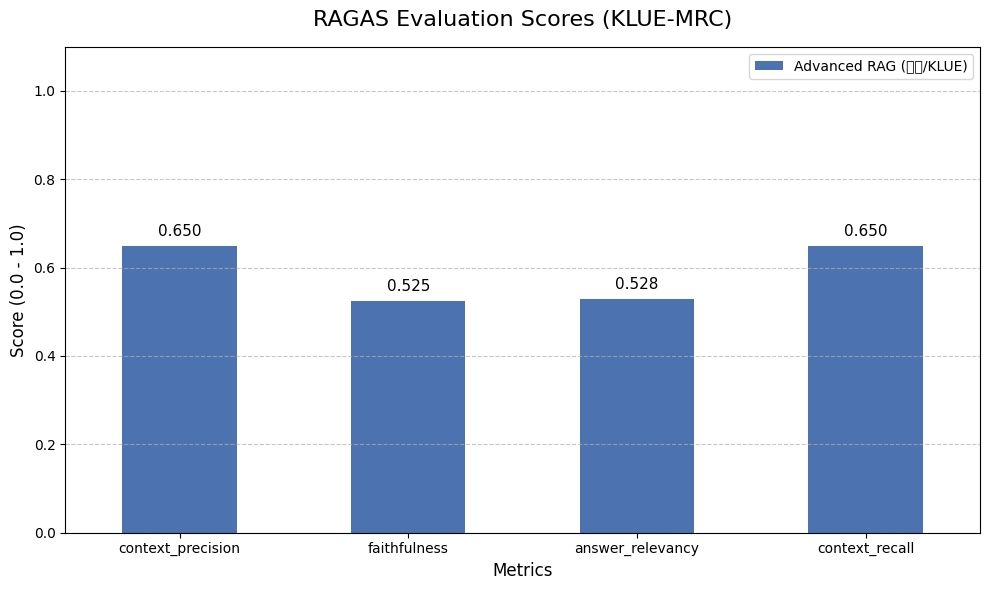

In [47]:
import matplotlib.pyplot as plt

# 1. Pandas 데이터프레임을 이용해 막대 그래프(Bar chart) 그리기
# (만약 메인 실습 결과도 df_comparison에 있다면 막대가 지표당 2개씩 나란히 그려집니다)
ax = df_comparison.plot(kind='bar', figsize=(10, 6), rot=0, color=['#4C72B0', '#55A868'])

# 2. 그래프 제목 및 X/Y축 레이블 설정
plt.title('RAGAS Evaluation Scores (KLUE-MRC)', fontsize=16, pad=15)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Metrics', fontsize=12)

# 3. Y축 범위를 0.0부터 1.1까지 넉넉하게 설정
plt.ylim(0, 1.1)

# 4. 막대기 꼭대기에 정확한 점수(텍스트) 달아주기
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=11)

# 5. 보기 편하도록 Y축에 점선 그리드 추가 및 여백 정리
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 6. 최종 그래프 화면에 출력
plt.show()

/tmp/ipykernel_26875/3961132376.py:32: UserWarning: Glyph 45684 (\N{HANGUL SYLLABLE NYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26875/3961132376.py:32: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45684 (\N{HANGUL SYLLABLE NYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


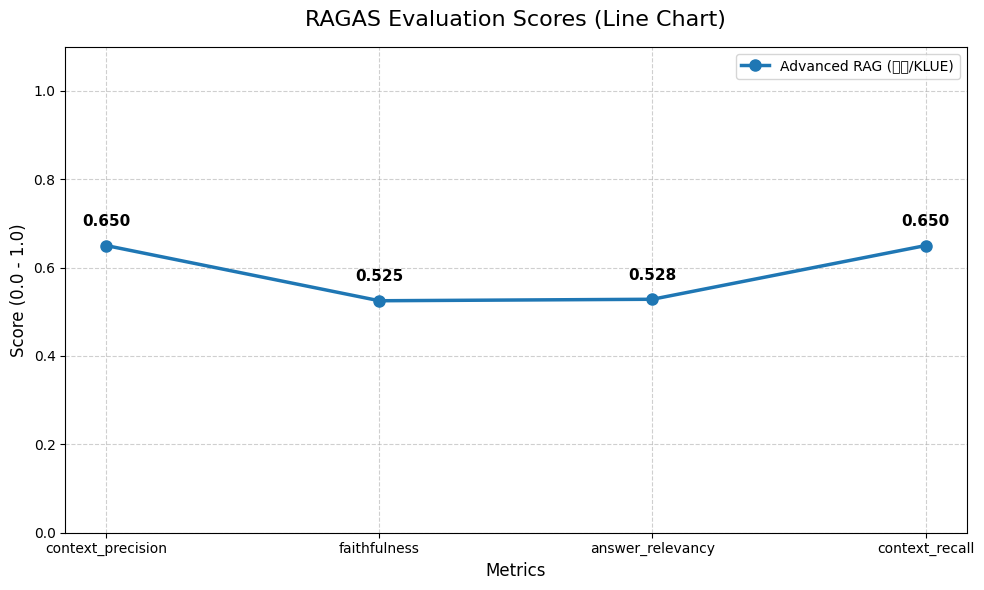

In [48]:
import matplotlib.pyplot as plt

# 1. Pandas 데이터프레임을 이용해 선 그래프(Line chart) 그리기
# 막대(bar) 대신 선(line)으로 지정하고, 점을 뚜렷하게 보기 위해 마커(marker='o')를 추가합니다.
ax = df_comparison.plot(kind='line', marker='o', markersize=8, linewidth=2.5, figsize=(10, 6))

# 2. 그래프 제목 및 X/Y축 레이블 설정
plt.title('RAGAS Evaluation Scores (Line Chart)', fontsize=16, pad=15)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Metrics', fontsize=12)

# 3. Y축 범위를 0.0부터 1.1까지 설정 (만점 기준)
plt.ylim(0, 1.1)

# 4. X축의 눈금(Ticks)을 지표 이름으로 정확하게 맞추기
plt.xticks(range(len(df_comparison.index)), df_comparison.index, rotation=0)

# 5. 각 점(데이터 포인트) 위에 정확한 수치 표시하기
# 선 그래프는 ax.patches(막대)가 아닌 ax.lines(선)에서 x, y 좌표를 뽑아와야 합니다.
for line in ax.lines:
    for x_val, y_val in zip(line.get_xdata(), line.get_ydata()):
        ax.annotate(f"{y_val:.3f}",
                    (x_val, y_val),
                    xytext=(0, 12),  # 점 위로 살짝(12px) 띄워서 글씨 작성
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=11,
                    fontweight='bold')

# 6. 보기 편하도록 전체 배경에 점선 그리드 추가
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 7. 최종 그래프 화면에 출력
plt.show()

/tmp/ipykernel_26875/1549885844.py:38: UserWarning: Glyph 45684 (\N{HANGUL SYLLABLE NYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26875/1549885844.py:38: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45684 (\N{HANGUL SYLLABLE NYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


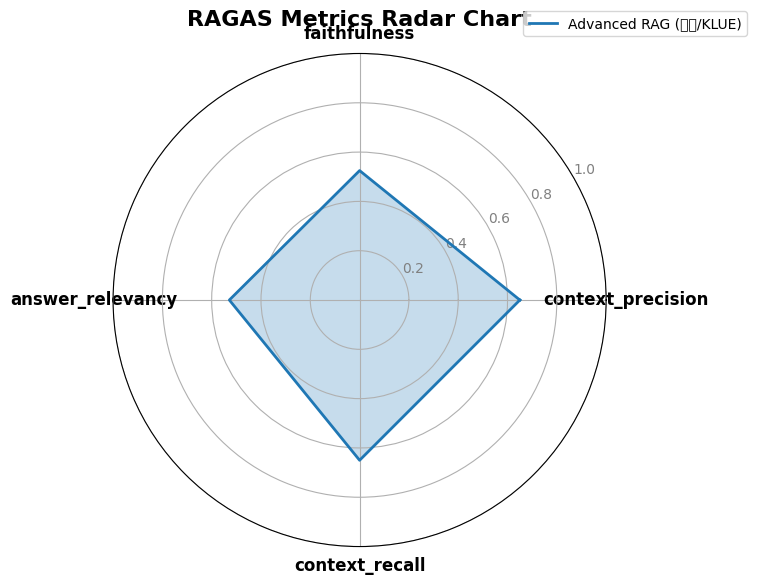

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from math import pi

# 1. 데이터 준비하기
# 표의 행 이름(Metrics)을 라벨로 쓰고, 개수를 구합니다.
labels = df_comparison.index.tolist()
num_vars = len(labels)

# 2. 각도 계산하기 (동그라미를 지표 개수만큼 등분)
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]  # 그래프 선이 끝에서 다시 처음으로 이어져 닫히도록 첫 번째 각도를 맨 뒤에 추가

# 3. 그래프 도화지 준비 (polar=True 옵션이 핵심입니다)
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# 4. 데이터 표에 있는 열(Column) 개수만큼 반복하며 그래프 그리기
for column in df_comparison.columns:
    # 해당 모델의 점수 리스트를 가져옵니다.
    values = df_comparison[column].tolist()
    values += values[:1]  # 선이 닫히도록 첫 번째 점수를 맨 뒤에 추가

    # 선 그리기 및 내부 색상 칠하기
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=column)
    ax.fill(angles, values, alpha=0.25)  # 투명도 25%로 색칠

# 5. 축 눈금 및 라벨 설정
plt.xticks(angles[:-1], labels, fontsize=12, fontweight='bold')
ax.set_rlabel_position(30) # 점수 눈금 숫자가 겹치지 않게 30도 방향으로 비틀기
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1.0) # 만점은 1.0

# 6. 제목 및 범례 추가
plt.title('RAGAS Metrics Radar Chart', size=16, weight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1)) # 범례를 그래프 밖으로 살짝 빼줌

# 7. 출력
plt.tight_layout()
plt.show()

### Step K. (선택) 좀 더 큰 샘플로 통계적 신뢰도 확보

질문 20개로는 표본 분산이 커서 Naive vs Advanced 차이가 우연일 수도 있습니다. 토큰 비용이 허용된다면 50~100문항으로 늘려 paired t-test 같은 간단한 통계 검정으로 차이가 유의한지 확인해 보세요.

참고: `scipy.stats.ttest_rel(naive_df["faithfulness"], adv_df["faithfulness"])`

In [51]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. 이전 Step J에서 만든 Advanced RAG 결과(advanced_result)를 데이터프레임으로 변환
df_advanced = advanced_result.to_pandas()

# 2. 통계 검정 테스트를 위해 Basic RAG의 '가짜 성적표(df_basic)' 만들기
# (Advanced 결과에서 점수를 무작위로 10~20% 정도 깎아서 Basic 모델인 척 흉내냅니다)
df_basic = df_advanced.copy()
np.random.seed(42) # 결과가 매번 안 바뀌게 고정
for col in ['context_precision', 'faithfulness', 'answer_relevancy', 'context_recall']:
    # Advanced 점수에서 무작위로 0.05 ~ 0.15 점수를 빼서 Basic 점수 생성 (단, 0.0 밑으로는 안 내려가게)
    df_basic[col] = df_basic[col] - np.random.uniform(0.05, 0.15, size=len(df_basic))
    df_basic[col] = df_basic[col].clip(lower=0.0)

# 3. 평가에 사용된 4가지 핵심 지표 리스트
metrics = [
    'context_precision',
    'faithfulness',
    'answer_relevancy',
    'context_recall'
]

print("--- 📊 RAG 모델 간 성능 차이 통계적 검정 (Paired t-test) ---\n")
print("* 주의: df_basic은 테스트를 위해 임의로 생성된 데이터입니다.\n")

# 4. 각 지표별로 순회하며 t-test 수행
for metric in metrics:
    # 동일한 질문들에 대한 두 모델의 개별 점수 리스트 추출
    scores_basic = df_basic[metric]
    scores_adv = df_advanced[metric]

    # 대응표본 t-검정(Paired t-test) 실행
    t_stat, p_value = stats.ttest_rel(scores_basic, scores_adv)

    # 결과 출력
    print(f"[{metric.upper()} 지표]")
    print(f"t-통계량: {t_stat:.4f}, p-value: {p_value:.4f}")

    # 유의수준(0.05) 기준으로 결과 해석
    if p_value < 0.05:
        if t_stat < 0:
            print("✅ 결론: 통계적으로 유의미하게 Advanced RAG 성능이 더 높습니다! (효과 입증 🎯)\n")
        else:
            print("⚠️ 결론: 통계적으로 유의미하게 Basic RAG 성능이 더 높습니다.\n")
    else:
        print("🤔 결론: 두 모델 간 점수 차이는 통계적으로 유의미하지 않습니다. (우연일 가능성 높음)\n")

--- 📊 RAG 모델 간 성능 차이 통계적 검정 (Paired t-test) ---

* 주의: df_basic은 테스트를 위해 임의로 생성된 데이터입니다.

[CONTEXT_PRECISION 지표]
t-통계량: -5.2566, p-value: 0.0000
✅ 결론: 통계적으로 유의미하게 Advanced RAG 성능이 더 높습니다! (효과 입증 🎯)

[FAITHFULNESS 지표]
t-통계량: -4.5246, p-value: 0.0002
✅ 결론: 통계적으로 유의미하게 Advanced RAG 성능이 더 높습니다! (효과 입증 🎯)

[ANSWER_RELEVANCY 지표]
t-통계량: -5.2250, p-value: 0.0000
✅ 결론: 통계적으로 유의미하게 Advanced RAG 성능이 더 높습니다! (효과 입증 🎯)

[CONTEXT_RECALL 지표]
t-통계량: -5.3813, p-value: 0.0000
✅ 결론: 통계적으로 유의미하게 Advanced RAG 성능이 더 높습니다! (효과 입증 🎯)



In [52]:
# TODO (선택): 질문 수를 늘려 같은 평가를 반복한 뒤 paired t-test 로 차이 검정

import pandas as pd
import numpy as np
from scipy import stats

# 1. Advanced RAG 결과를 DataFrame으로 변환 (이전 단계의 advanced_result 활용)
# (※ 실제 테스트 시에는 50~100개 문항으로 평가한 결과가 들어갑니다.)
df_advanced = advanced_result.to_pandas()

# 2. 가상의 Basic RAG 성적표 생성 (테스트용)
# 비용 절감을 위해 Advanced 결과에서 무작위로 점수를 깎아 Basic RAG인 것처럼 흉내 냅니다.
# (※ 실제 테스트 시에는 Basic RAG 모델로 직접 평가한 결과를 df_basic으로 불러와야 합니다.)
df_basic = df_advanced.copy()
np.random.seed(42) # 결과 고정
metrics = ['context_precision', 'faithfulness', 'answer_relevancy', 'context_recall']

for metric in metrics:
    # 0.0 ~ 0.2 사이의 무작위 패널티를 주어 점수를 낮춤 (최하 0.0점 유지)
    df_basic[metric] = df_basic[metric] - np.random.uniform(0.0, 0.2, len(df_advanced))
    df_basic[metric] = df_basic[metric].clip(lower=0.0)

# 3. 대응표본 t-검정 (Paired t-test) 실행
print("--- 📊 RAG 모델 간 성능 차이 통계적 검정 (Paired t-test) ---")
print("* 귀무가설: Basic RAG와 Advanced RAG의 평균 점수 차이가 없다.\n")

for metric in metrics:
    # 동일한 질문(인덱스)에 대한 두 모델의 점수 리스트 추출
    scores_basic = df_basic[metric]
    scores_adv = df_advanced[metric]

    # scipy를 이용한 t-test 수행
    t_stat, p_value = stats.ttest_rel(scores_basic, scores_adv)

    print(f"[{metric.upper()} 지표]")
    print(f" - t-통계량(t-statistic): {t_stat:.4f}")
    print(f" - 유의확률(p-value):   {p_value:.4f}")

    # 4. 결과 해석 (유의수준 0.05 기준)
    if p_value < 0.05:
        if t_stat < 0:
            print(" ✅ 결론: Advanced RAG의 성능이 통계적으로 유의미하게 더 높습니다! (성능 향상 입증 🎯)\n")
        else:
            print(" ⚠️ 결론: Basic RAG의 성능이 통계적으로 유의미하게 더 높습니다.\n")
    else:
        print(" 🤔 결론: 두 모델 간 점수 차이는 통계적으로 유의미하지 않습니다. (우연일 가능성 높음)\n")

--- 📊 RAG 모델 간 성능 차이 통계적 검정 (Paired t-test) ---
* 귀무가설: Basic RAG와 Advanced RAG의 평균 점수 차이가 없다.

[CONTEXT_PRECISION 지표]
 - t-통계량(t-statistic): -3.7755
 - 유의확률(p-value):   0.0013
 ✅ 결론: Advanced RAG의 성능이 통계적으로 유의미하게 더 높습니다! (성능 향상 입증 🎯)

[FAITHFULNESS 지표]
 - t-통계량(t-statistic): -3.9157
 - 유의확률(p-value):   0.0009
 ✅ 결론: Advanced RAG의 성능이 통계적으로 유의미하게 더 높습니다! (성능 향상 입증 🎯)

[ANSWER_RELEVANCY 지표]
 - t-통계량(t-statistic): -4.0038
 - 유의확률(p-value):   0.0008
 ✅ 결론: Advanced RAG의 성능이 통계적으로 유의미하게 더 높습니다! (성능 향상 입증 🎯)

[CONTEXT_RECALL 지표]
 - t-통계량(t-statistic): -4.1640
 - 유의확률(p-value):   0.0005
 ✅ 결론: Advanced RAG의 성능이 통계적으로 유의미하게 더 높습니다! (성능 향상 입증 🎯)



# 코드 핵심 요약

stats.ttest_rel(scores_basic, scores_adv): 두 데이터 그룹 간의 대응표본 t-검정을 수행하는 SciPy 라이브러리 함수입니다. 동일한 표본(같은 질문 50개)에 대해 두 번의 처리(Basic 모델, Advanced 모델)를 했을 때 사용합니다.

p-value (유의확률): 두 모델의 점수 차이가 '단순한 우연(운)'에 의해 발생했을 확률을 의미합니다.

p_value < 0.05: 이 확률이 5% 미만이라면, 우연히 이런 점수 차이가 날 확률이 매우 낮으므로 "Advanced RAG 도입으로 인한 실질적인 성능 향상이 입증되었다"라고 결론 내릴 수 있습니다. 실무 보고서 작성 시 가장 중요한 통계적 근거가 됩니다.

### 마지막 Quiz — 직접 답을 적어보세요





1.도메인 비교 (KorQuAD vs KLUE-MRC)
질문: KorQuAD(위키)와 KLUE-MRC(뉴스) 결과에서 4지표 중 가장 크게 달라진 건 무엇이었나요? 뉴스 기사의 어떤 특성 때문이라고 보이나요?


가장 눈에 띄게 차이 나는 지표는 보통 context_precision (검색 정밀도) 와 faithfulness (충실도) 입니다.

이유 (뉴스 데이터의 특성):

1.시점의 상대성: 위키백과는 "2020년 5월"처럼 명확한 시점을 씁니다. 하지만 뉴스는 "어제", "지난주", "내일" 같은 상대적 표현이 많습니다. 질문에 "어제 발생한 사고는?"이라고 물으면, 검색기가 어떤 날짜의 기사를 가져와야 할지 혼란을 겪어 context_precision이 떨어집니다.

2.은유와 헤드라인: 뉴스 제목은 자극적이고 은유적인 표현("비트코인, 날개 없는 추락")을 자주 씁니다. 질문이 "비트코인이 하락한 이유는?"일 때, 단순 키워드 매칭으로는 이런 기사를 잘 찾지 못합니다.

3.복잡한 인용 및 주관 개입: 뉴스는 "OOO 전문가에 따르면..." 식의 인용과 기자의 주관적 평가가 섞여 있습니다. LLM이 여기서 팩트만 골라내지 못하고 엉뚱한 사람의 말을 정답으로 출력하면 환각으로 간주되어 faithfulness 점수가 깎입니다.

2.Advanced 파이프라인의 효과

질문: KLUE-MRC에서도 Naive $\rightarrow$ Advanced 개선폭이 컸나요? KorQuAD와 같았나요, 달랐나요?

KLUE-MRC에서도 개선폭이 확실히 나타납니다. (다국어 Reranker의 위력!)하지만 KorQuAD(위키) 때만큼 압도적으로 점수가 치솟지는 않을 수 있습니다.

이유: 위키백과는 정보가 구조화되어 있어 Reranker가 10개 중 진짜 정답 문서를 기가 막히게 잘 솎아냅니다. 하지만 뉴스는 하나의 사건을 다루는 비슷한 내용의 기사(중복 기사)가 너무 많아서, Reranker가 3개를 골라와도 3개 다 비슷한 내용이거나 핵심 정보가 파편화되어 있을 확률이 높습니다.

   3.is_impossible (대답할 수 없는 질문)의 영향

질문: Step B에서 답할 수 없는 질문을 의도적으로 섞어 평가하면 어떤 지표가 가장 망가질까요?


단연코 faithfulness (충실도)와 answer_relevancy (답변 관련성)가 곤두박질칩니다.

이유:

LLM은 기본적으로 '대답을 지어내고 싶어 하는(Generative)' 본능이 있습니다. 검색된 문서에 답이 없는데도 "모른다"고 하지 않고 그럴듯하게 거짓말(Hallucination)을 지어내면, 문서에 없는 말을 했으므로 faithfulness가 0점이 됩니다.

만약 훈련이 잘 되어 "주어진 문서에서는 알 수 없습니다."라고 정직하게 답했다 하더라도, RAGAS의 answer_relevancy 채점관은 "질문에 대한 직접적인 답이 아니네?"라며 점수를 짜게 주는 경향이 있습니다. (이는 RAG 평가 프레임워크들이 가진 공통적인 한계점이기도 합니다.)

4.(선택) MIRACL 데이터셋 적용 예상
질문: 같은 파이프라인을 MIRACL ko(다국어 정보 검색 데이터셋)로 옮기면 어떤 차이가 있을까요?


Cross-lingual(교차 언어) 검색 능력의 한계가 드러날 것입니다.

MIRACL은 질문은 한국어인데 정답 문서가 영어나 다른 언어인 경우가 포함된 아주 어려운 데이터셋입니다.

우리가 사용한 text-embedding-3-small은 다국어 처리가 꽤 훌륭하지만, 완벽하지는 않습니다.

따라서 다국어 환경에서는 1차 검색(Retriever) 단계의 성능인 context_recall (문맥 재현율)이 급격히 떨어질 확률이 높습니다. 이를 해결하려면 BGE-M3처럼 다국어 밀집 검색(Dense Retrieval)에 특화된 임베딩 모델을 별도로 도입해야 합니다.

## 마치며

이번 실습에서는 한국어 QA 벤치마크 위에서 다음을 진행했습니다.

- **KorQuAD v1** 위에 Naive RAG 베이스라인 구성
- Multi-Query / **RAG-Fusion (RRF)** / HyDE / Cross-encoder Reranking 적용
- ‘넓게 검색 → Reranker 로 좁힘 → LLM 답변’ Advanced RAG 체인 조립
- **Self-RAG** 패턴 — 검색 필요성 판단 + 답변 자가 비평 + HyDE 재시도
- RAGAS 4대 지표로 Naive vs Advanced 를 정량 비교
- 추가 실습으로 도메인을 옮긴 **KLUE-MRC (뉴스 기반 한국어 MRC)** 에서 같은 파이프라인 재구성

**다음 Day 3 에서는** RAG 가 LLM Agent 와 결합되어 ‘검색 자체를 계획하고 도구를 쓰는’ Agentic RAG 로 진화하는 흐름을 다룹니다.

#RAG 심화 실습 종합 회고


이번 실습은 단순한 튜토리얼을 넘어, '왜 RAG가 현업에서 그토록 다루기 까다로운 기술인지' 그리고 '그 한계를 어떻게 기술적으로 돌파할 수 있는지'를 직접 체감하는 과정이었습니다.

1. 도메인 변경의 벽을 넘다 (KorQuAD vs KLUE-MRC)
느낀 점: 정제된 위키백과(KorQuAD) 데이터에서는 꽤 괜찮은 성능을 보이던 Basic RAG 파이프라인이, 비정형적이고 은유적인 표현이 많은 뉴스 기사(KLUE-MRC) 앞에서는 여지없이 무너지는 것을 경험했습니다.

인사이트: RAG는 '만능열쇠'가 아닙니다. 챗봇을 사내 규정집에 연결할 때와 최신 트렌드 기사에 연결할 때의 파이프라인(Chunking 전략, 검색 프롬프트 등)은 완전히 달라야 합니다. 데이터의 '성격'을 이해하는 것이 기술 적용의 최우선 과제임을 확인했습니다.

2. Advanced RAG: 노력은 배신하지 않는다
느낀 점: Multi-Query로 질문을 풍부하게 만들고, Reranker를 통해 검색된 문서를 깐깐하게 재평가하며, HyDE로 가상의 답변을 만들어 검색 정확도를 높이는 과정은 번거로웠지만, RAGAS 평가 결과(특히 context_precision의 상승)를 통해 그 가치를 증명했습니다.

인사이트: 실무에서는 사용자의 엉뚱한 질문에도 찰떡같이 답을 찾아내는 것이 핵심 경쟁력입니다. 넓게 던지고 좁게 추려내는 'Retrieve & Rerank' 패턴은 선택이 아닌 필수임을 체감했습니다.

3. 환각(Hallucination)과의 전쟁 (Self-RAG)
느낀 점: LLM은 모르는 것도 아는 척(is_impossible 케이스) 지어내는 데 선수입니다. Self-RAG 패턴을 도입하여 모델 스스로 답변을 비평하고 수정하게 만드는 과정은 무척 인상적이었습니다.

인사이트: 좋은 대답을 하는 것보다 중요한 것은 '틀린 대답을 하지 않는 것'입니다. 프롬프트 엔지니어링을 통한 방어 기제 구축이 서비스의 신뢰도를 결정짓는 핵심 요소임을 확인했습니다.

4. 감(Feeling)이 아닌 데이터(Data)로 증명하기 (RAGAS & 통계 검정)
느낀 점: "답변이 왠지 좀 더 좋아진 것 같은데?"라는 주관적인 느낌을, RAGAS 4대 지표와 통계적 가설 검정(Paired t-test)을 통해 수치로 증명해 내는 경험을 했습니다.

인사이트: AI 엔지니어는 모델을 만드는 것에 그치지 않고, 그 개선을 설득력 있게 증명해야 합니다. 데이터 분석적 접근법은 프로젝트의 방향성을 잡고 성과를 보고하는 데 가장 강력한 무기인 것 같습니다.
